# Analyzing the results of counterfactual explanations on MNIST


In [316]:
# import relevant packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # use deep

In [260]:
# import results
results = pd.read_csv('results/mnist_full_results_updated.csv', index_col=0)
results.head(10)

,network,image,original_label,original_predicted_label,predicted_label,target,method,IM1,IM2,correctness,...,linf,implausibility,morans_i_original,morans_i_explanation,morans_i_original_minus_explanation,optim_time,correctness_ratio,weak_correctness,morans_i_difference,timeout
0,mnist_output_100,0.0,7,7,NaN,0.0,alibi-CF,NaN,NaN,0,...,NaN,NaN,0.722879,NaN,NaN,4.768510,0.0,0,NaN,1.0
1,mnist_output_100,0.0,7,7,NaN,1.0,alibi-CF,NaN,NaN,0,...,NaN,NaN,0.722879,NaN,NaN,4.600064,0.0,0,NaN,1.0
2,mnist_output_100,0.0,7,7,NaN,2.0,alibi-CF,NaN,NaN,0,...,NaN,NaN,0.722879,NaN,NaN,3.915866,0.0,0,NaN,1.0
3,mnist_output_100,0.0,7,7,NaN,3.0,alibi-CF,NaN,NaN,0,...,NaN,NaN,0.722879,NaN,NaN,3.973385,0.0,0,NaN,1.0
4,mnist_output_100,0.0,7,7,NaN,4.0,alibi-CF,NaN,NaN,0,...,NaN,NaN,0.722879,NaN,NaN,3.924591,0.0,0,NaN,1.0
5,mnist_output_100,0.0,7,7,NaN,5.0,alibi-CF,NaN,NaN,0,...,NaN,NaN,0.722879,NaN,NaN,4.046250,0.0,0,NaN,1.0
6,mnist_output_100,0.0,7,7,NaN,6.0,alibi-CF,NaN,NaN,0,...,NaN,NaN,0.722879,NaN,NaN,4.278754,0.0,0,NaN,1.0
7,mnist_output_100,0.0,7,7,NaN,8.0,alibi-CF,NaN,NaN,0,...,NaN,NaN,0.722879,NaN,NaN,4.862746,0.0,0,NaN,1.0
8,mnist_output_100,0.0,7,7,NaN,9.0,alibi-CF,NaN,NaN,0,...,NaN,NaN,0.722879,NaN,NaN,4.208386,0.0,0,NaN,1.0
9,mnist_output_100,1.0,2,2,NaN,0.0,alibi-CF,NaN,NaN,0,...,NaN,NaN,0.762163,NaN,NaN,4.192075,0.0,0,NaN,1.0


In [261]:
results = results.rename(columns={'correctness': 'success', 'weak_correctness': 'weak_success', 'correctness_ratio': 'success_ratio'})
results

,network,image,original_label,original_predicted_label,predicted_label,target,method,IM1,IM2,success,...,linf,implausibility,morans_i_original,morans_i_explanation,morans_i_original_minus_explanation,optim_time,success_ratio,weak_success,morans_i_difference,timeout
0,mnist_output_100,0.0,7,7,NaN,0.0,alibi-CF,NaN,NaN,0,...,NaN,NaN,0.722879,NaN,NaN,4.768510,0.0,0,NaN,1.0
1,mnist_output_100,0.0,7,7,NaN,1.0,alibi-CF,NaN,NaN,0,...,NaN,NaN,0.722879,NaN,NaN,4.600064,0.0,0,NaN,1.0
2,mnist_output_100,0.0,7,7,NaN,2.0,alibi-CF,NaN,NaN,0,...,NaN,NaN,0.722879,NaN,NaN,3.915866,0.0,0,NaN,1.0
3,mnist_output_100,0.0,7,7,NaN,3.0,alibi-CF,NaN,NaN,0,...,NaN,NaN,0.722879,NaN,NaN,3.973385,0.0,0,NaN,1.0
4,mnist_output_100,0.0,7,7,NaN,4.0,alibi-CF,NaN,NaN,0,...,NaN,NaN,0.722879,NaN,NaN,3.924591,0.0,0,NaN,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27319,mnist_schut_mlp_output,98.0,6,6,6.0,4.0,PIECE,1.0,0.051976,0,...,1.992157,342.92554,0.709559,0.586605,0.519112,29.422554,0.0,0,0.122954,0.0
27320,mnist_schut_mlp_output,98.0,6,6,6.0,5.0,PIECE,1.0,0.027526,0,...,1.991785,399.54440,0.709559,0.688892,0.462643,29.331965,0.0,0,0.020667,0.0
27321,mnist_schut_mlp_output,98.0,6,6,6.0,7.0,PIECE,1.0,0.029841,0,...,1.992157,433.02762,0.709559,0.659100,0.502906,29.518147,0.0,0,0.050459,0.0
27322,mnist_schut_mlp_output,98.0,6,6,6.0,8.0,PIECE,1.0,0.028693,0,...,1.984222,465.63928,0.709559,0.653260,0.591543,29.591588,0.0,0,0.056299,0.0


In [262]:
results[results['method'] == 'alibi-Proto-CF'][results['network'] == 'mnist_cnn_output_100'][results['predicted_label'].notna()]

C:\Users\Jasmin\AppData\Local\Temp\ipykernel_23656\1420616722.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  results[results['method'] == 'alibi-Proto-CF'][results['network'] == 'mnist_cnn_output_100'][results['predicted_label'].notna()]
C:\Users\Jasmin\AppData\Local\Temp\ipykernel_23656\1420616722.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  results[results['method'] == 'alibi-Proto-CF'][results['network'] == 'mnist_cnn_output_100'][results['predicted_label'].notna()]


,network,image,original_label,original_predicted_label,predicted_label,target,method,IM1,IM2,success,...,linf,implausibility,morans_i_original,morans_i_explanation,morans_i_original_minus_explanation,optim_time,success_ratio,weak_success,morans_i_difference,timeout
5449,mnist_cnn_output_100,0.0,7,7,4.0,4.0,alibi-Proto-CF,1.700308,0.264895,1,...,1.806576,401.28604,0.722879,0.644151,0.521091,50.995885,0.111111,1,0.078728,0.0
5457,mnist_cnn_output_100,1.0,2,2,4.0,4.0,alibi-Proto-CF,1.631145,0.204935,1,...,2.000000,658.09610,0.762163,0.507740,0.310283,52.535036,0.333333,1,0.254423,0.0
5460,mnist_cnn_output_100,1.0,2,2,7.0,7.0,alibi-Proto-CF,1.130343,0.239166,1,...,0.827351,494.01685,0.762163,0.766082,0.368028,53.014567,0.333333,1,0.003919,0.0
5461,mnist_cnn_output_100,1.0,2,2,8.0,8.0,alibi-Proto-CF,1.038547,0.159498,1,...,2.000000,991.91644,0.762163,0.349706,0.304719,55.708626,0.333333,1,0.412457,0.0
5466,mnist_cnn_output_100,2.0,1,1,4.0,4.0,alibi-Proto-CF,0.494779,0.235471,1,...,1.723115,612.82697,0.686809,0.438985,0.490378,54.207111,0.333333,1,0.247824,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6322,mnist_cnn_output_100,97.0,7,7,4.0,4.0,alibi-Proto-CF,1.717184,0.185293,1,...,2.000000,764.38495,0.815126,0.584983,0.502058,317.422611,0.222222,1,0.230143,0.0
6325,mnist_cnn_output_100,97.0,7,7,8.0,8.0,alibi-Proto-CF,1.125826,0.212410,1,...,2.000000,1483.72020,0.815126,0.034203,0.066145,318.434300,0.222222,1,0.780924,0.0
6331,mnist_cnn_output_100,98.0,6,6,4.0,4.0,alibi-Proto-CF,1.118024,0.212838,1,...,1.927250,635.56805,0.709559,0.496918,0.415007,321.087958,0.333333,1,0.212641,0.0
6333,mnist_cnn_output_100,98.0,6,6,7.0,7.0,alibi-Proto-CF,0.812112,0.328084,1,...,1.808143,378.31656,0.709559,0.691471,0.432453,319.925344,0.333333,1,0.018088,0.0


In [263]:
# fix correctness and weak correctness for captum
results.loc[results['method'] == 'Captum-MinParamPerturbation', 'success'] = (
    results.loc[results['method'] == 'Captum-MinParamPerturbation']
    .apply(lambda row: 1 if pd.notna(row['predicted_label']) and row['original_predicted_label'] != row['predicted_label'] else 0, axis=1)
)

In [264]:
results['weak_success'] = results.groupby(['network', 'method', 'image'])['success'].transform('max')

## Question 1: How many instances can the method successfully find an explanation for? 

- Are timeouts equivalent to success?
- Are some methods more successful than others? 
- Does this change per network?
- Are certain decision changes more successful than others?
- Is success correlated with something?

In [265]:
results[results['timeout'] == 1].groupby(['success', 'method', 'network']).count()['timeout']

success  method                       network               
0        C-Min-Edit                   mnist_alibi_cnn_output    125
                                      mnist_cnn_output_100       40
                                      mnist_lenet5_output       206
                                      mnist_output_100           14
                                      mnist_resnet8_output       96
         Captum-MinParamPerturbation  mnist_lenet5_output         1
         Min-Edit                     mnist_alibi_cnn_output    150
                                      mnist_cnn_output_100       95
                                      mnist_lenet5_output       281
                                      mnist_output_100           33
                                      mnist_resnet8_output      151
         PIECE                        mnist_alibi_cnn_output    553
                                      mnist_cnn_output_100      205
                                      mnist_lenet5_outp

In [266]:
results[results['timeout'] == 0].groupby(['success', 'method', 'network']).count()['timeout']

success  method                       network               
0        C-Min-Edit                   mnist_alibi_cnn_output    239
                                      mnist_cnn_output_100      188
                                      mnist_lenet5_output       326
                                      mnist_output_100          104
                                      mnist_resnet8_output      222
                                      mnist_schut_mlp_output    116
         Captum-MinParamPerturbation  mnist_alibi_cnn_output     73
                                      mnist_cnn_output_100       99
                                      mnist_lenet5_output        34
                                      mnist_output_100            2
                                      mnist_schut_mlp_output      3
         Min-Edit                     mnist_alibi_cnn_output    219
                                      mnist_cnn_output_100      207
                                      mnist_lenet5_outp

What does this tell us? For 9 instances of alibi-CF where it did not timeout (i.e. an explanation was found), but that explanation was incorrect. This happens only for mlp_relu_1024. For Captum, there are 73,99,34,2 and 3 examples where it did not time out (i.e. an explanation was found) but the explanation was incorrect. This happens for all except one network (that one is resnet 18). Lastly, the PIECE-paper based methods all seem to have the problem over all networks. Is this a bug in the code?

In [267]:
results[results['timeout'] == 0][results['method'] == 'alibi-CF'][results['success'] == 0]

C:\Users\Jasmin\AppData\Local\Temp\ipykernel_23656\2132247822.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  results[results['timeout'] == 0][results['method'] == 'alibi-CF'][results['success'] == 0]
C:\Users\Jasmin\AppData\Local\Temp\ipykernel_23656\2132247822.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  results[results['timeout'] == 0][results['method'] == 'alibi-CF'][results['success'] == 0]


,network,image,original_label,original_predicted_label,predicted_label,target,method,IM1,IM2,success,...,linf,implausibility,morans_i_original,morans_i_explanation,morans_i_original_minus_explanation,optim_time,success_ratio,weak_success,morans_i_difference,timeout
104,mnist_output_100,11.0,6,6,6.0,5.0,alibi-CF,1.0,0.052196,0,...,0.204030,442.46150,0.679708,0.671707,0.133795,10.680742,0.0,0,0.008000,0.0
234,mnist_output_100,26.0,7,7,7.0,0.0,alibi-CF,1.0,0.031938,0,...,0.831003,480.17730,0.662333,0.639672,0.025927,17.567457,0.0,0,0.022661,0.0
340,mnist_output_100,37.0,1,1,1.0,8.0,alibi-CF,1.0,0.832490,0,...,0.118425,367.04535,0.786220,0.780731,0.237390,23.507417,0.0,0,0.005489,0.0
390,mnist_output_100,43.0,2,2,2.0,4.0,alibi-CF,1.0,0.028877,0,...,0.662970,376.74896,0.662704,0.646341,0.079387,26.436002,0.0,0,0.016363,0.0
447,mnist_output_100,49.0,4,4,4.0,7.0,alibi-CF,1.0,0.027475,0,...,0.566793,386.68945,0.739501,0.734287,0.137991,32.412744,0.0,0,0.005214,0.0
654,mnist_output_100,72.0,2,2,2.0,7.0,alibi-CF,1.0,0.023228,0,...,0.380285,479.77750,0.700449,0.681999,0.149676,45.005337,0.0,0,0.018451,0.0
661,mnist_output_100,73.0,9,9,9.0,4.0,alibi-CF,1.0,0.017244,0,...,0.238292,411.17600,0.857194,0.849811,0.223546,45.212364,0.0,0,0.007383,0.0
789,mnist_output_100,87.0,3,3,3.0,7.0,alibi-CF,1.0,0.024921,0,...,0.218190,424.33295,0.752487,0.750948,0.145867,57.058424,0.0,0,0.001540,0.0
852,mnist_output_100,94.0,1,1,1.0,7.0,alibi-CF,1.0,0.762300,0,...,0.425540,382.10535,0.863092,0.851906,0.058576,59.992121,0.0,0,0.011186,0.0


In [268]:
results[results['timeout'] == 0][results['method'] == 'Captum-MinParamPerturbation'][results['success'] == 0].tail(50)

C:\Users\Jasmin\AppData\Local\Temp\ipykernel_23656\1063402956.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  results[results['timeout'] == 0][results['method'] == 'Captum-MinParamPerturbation'][results['success'] == 0].tail(50)
C:\Users\Jasmin\AppData\Local\Temp\ipykernel_23656\1063402956.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  results[results['timeout'] == 0][results['method'] == 'Captum-MinParamPerturbation'][results['success'] == 0].tail(50)


,network,image,original_label,original_predicted_label,predicted_label,target,method,IM1,IM2,success,...,linf,implausibility,morans_i_original,morans_i_explanation,morans_i_original_minus_explanation,optim_time,success_ratio,weak_success,morans_i_difference,timeout
11862,mnist_alibi_cnn_output,81.0,6,6,6.0,NaN,Captum-MinParamPerturbation,1.0,0.209781,0,...,1.0,529.13220,0.780318,0.637911,0.635540,0.147789,0.0,0,0.142407,0.0
11864,mnist_alibi_cnn_output,83.0,7,7,7.0,NaN,Captum-MinParamPerturbation,1.0,0.204716,0,...,1.0,346.41138,0.722964,0.697958,0.637517,0.127816,0.0,0,0.025006,0.0
11865,mnist_alibi_cnn_output,84.0,8,8,8.0,NaN,Captum-MinParamPerturbation,1.0,0.130107,0,...,1.0,418.23483,0.706365,0.695051,0.655605,0.121001,0.0,0,0.011314,0.0
11866,mnist_alibi_cnn_output,85.0,4,4,4.0,NaN,Captum-MinParamPerturbation,1.0,0.189891,0,...,1.0,670.21857,0.863112,0.656542,0.677972,0.166330,0.0,0,0.206570,0.0
11868,mnist_alibi_cnn_output,87.0,3,3,3.0,NaN,Captum-MinParamPerturbation,1.0,0.074639,0,...,1.0,398.89365,0.752487,0.722012,0.684250,0.110676,0.0,0,0.030475,0.0
11869,mnist_alibi_cnn_output,88.0,6,6,6.0,NaN,Captum-MinParamPerturbation,1.0,0.192448,0,...,1.0,653.21370,0.767270,0.568753,0.630092,0.174420,0.0,0,0.198516,0.0
11870,mnist_alibi_cnn_output,89.0,1,1,1.0,NaN,Captum-MinParamPerturbation,1.0,0.700532,0,...,1.0,231.57841,0.829487,0.766866,0.683394,0.118396,0.0,0,0.062622,0.0
11872,mnist_alibi_cnn_output,91.0,6,6,6.0,NaN,Captum-MinParamPerturbation,1.0,0.162577,0,...,1.0,363.81918,0.737310,0.659540,0.657239,0.119645,0.0,0,0.077770,0.0
11874,mnist_alibi_cnn_output,93.0,3,3,3.0,NaN,Captum-MinParamPerturbation,1.0,0.124993,0,...,1.0,412.06490,0.882469,0.790908,0.653037,0.118938,0.0,0,0.091561,0.0
11875,mnist_alibi_cnn_output,94.0,1,1,1.0,NaN,Captum-MinParamPerturbation,1.0,0.775913,0,...,1.0,305.74603,0.863092,0.794474,0.690083,0.119215,0.0,0,0.068618,0.0


In [269]:
results[results['timeout'] == 0][results['method'] == 'PIECE'][results['success'] == 0].tail(50)

C:\Users\Jasmin\AppData\Local\Temp\ipykernel_23656\2569938248.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  results[results['timeout'] == 0][results['method'] == 'PIECE'][results['success'] == 0].tail(50)
C:\Users\Jasmin\AppData\Local\Temp\ipykernel_23656\2569938248.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  results[results['timeout'] == 0][results['method'] == 'PIECE'][results['success'] == 0].tail(50)


,network,image,original_label,original_predicted_label,predicted_label,target,method,IM1,IM2,success,...,linf,implausibility,morans_i_original,morans_i_explanation,morans_i_original_minus_explanation,optim_time,success_ratio,weak_success,morans_i_difference,timeout
27251,mnist_schut_mlp_output,90.0,3,3,3.0,9.0,PIECE,1.000000,0.022357,0,...,1.993728,392.91956,0.724204,0.547539,0.459555,29.461616,0.000000,0,0.176666,0.0
27252,mnist_schut_mlp_output,91.0,6,6,6.0,0.0,PIECE,1.000000,0.041165,0,...,1.984212,455.81763,0.737310,0.605176,0.559499,29.203394,0.111111,1,0.132134,0.0
27253,mnist_schut_mlp_output,91.0,6,6,6.0,1.0,PIECE,1.000000,0.022682,0,...,2.000000,186.52460,0.737310,0.696297,0.665801,29.347768,0.111111,1,0.041014,0.0
27254,mnist_schut_mlp_output,91.0,6,6,6.0,2.0,PIECE,1.000000,0.017393,0,...,1.994643,382.18880,0.737310,0.668843,0.604957,29.383142,0.111111,1,0.068467,0.0
27255,mnist_schut_mlp_output,91.0,6,6,6.0,3.0,PIECE,1.000000,0.028100,0,...,2.000000,337.98312,0.737310,0.580905,0.626067,29.484529,0.111111,1,0.156406,0.0
27256,mnist_schut_mlp_output,91.0,6,6,6.0,4.0,PIECE,1.000000,0.021428,0,...,1.911277,331.06076,0.737310,0.632484,0.493734,29.212227,0.111111,1,0.104826,0.0
27257,mnist_schut_mlp_output,91.0,6,6,6.0,5.0,PIECE,1.000000,0.049200,0,...,1.984312,342.26608,0.737310,0.657561,0.490805,29.503605,0.111111,1,0.079750,0.0
27258,mnist_schut_mlp_output,91.0,6,6,6.0,7.0,PIECE,1.000000,0.026478,0,...,1.696226,364.89505,0.737310,0.625702,0.371489,29.312443,0.111111,1,0.111609,0.0
27259,mnist_schut_mlp_output,91.0,6,6,6.0,8.0,PIECE,1.000000,0.025601,0,...,1.995490,338.39807,0.737310,0.742890,0.540047,29.288938,0.111111,1,0.005579,0.0
27262,mnist_schut_mlp_output,92.0,9,4,8.0,1.0,PIECE,0.791635,0.039803,0,...,1.988432,248.93973,0.590049,0.676828,0.545972,29.259718,0.666667,1,0.086779,0.0


In [270]:
# cases where the network was incorrectly classifying images
results[results['original_predicted_label'] != results['original_label']].groupby(['method']).count()

,network,image,original_label,original_predicted_label,predicted_label,target,IM1,IM2,success,l1,...,linf,implausibility,morans_i_original,morans_i_explanation,morans_i_original_minus_explanation,optim_time,success_ratio,weak_success,morans_i_difference,timeout
method,,,,,,,,,,,,,,,,,,,,,
C-Min-Edit,63,63,63,63,63,63,63,63,63,63,...,63,63,63,63,63,63,63,63,63,63
Captum-MinParamPerturbation,114,114,114,114,113,0,113,113,114,113,...,113,113,114,113,113,114,114,114,113,114
Min-Edit,63,63,63,63,63,63,63,63,63,63,...,63,63,63,63,63,63,63,63,63,63
PIECE,63,63,63,63,63,63,63,63,63,63,...,63,63,63,63,63,63,63,63,63,63
alibi-CF,36,36,36,36,27,36,27,27,36,27,...,27,27,36,27,27,36,36,36,27,36
alibi-Proto-CF,36,36,36,36,27,36,27,27,36,27,...,27,27,36,27,27,36,36,36,27,36


Okay so what I believe may be happening is that either the method legit times out and therefore gives a wring explanation. Or there is some bug somewhere that causes wrong explanations. For PIECE, C-min-Edit and Min-edit this could be the way we check if the prediction is the same as the target. For Captum it usually means it cannot change the original prediction. For alibi-CF, it's all for one particular network and the prediction just can't change. 

In [271]:
sum_correctness = results.groupby('method')['success'].sum()
count_correctness = results.groupby('method')['success'].count()
percentage_correctness = (sum_correctness / count_correctness) * 100

# Display percentage of correct instances (including failed attempts NaNs)
print(percentage_correctness)

method
C-Min-Edit                     68.649458
Captum-MinParamPerturbation    64.309764
Min-Edit                       61.690984
PIECE                          27.216611
alibi-CF                       60.549944
alibi-Proto-CF                 67.209128
Name: success, dtype: float64


In [273]:
sum_correctness = results.groupby('method')['weak_success'].sum()
count_correctness = results.groupby('method')['weak_success'].count()
percentage_correctness = (sum_correctness / count_correctness) * 100

# Display percentage of correct instances (including failed attempts NaNs)
print(percentage_correctness)

method
C-Min-Edit                      98.821549
Captum-MinParamPerturbation     64.309764
Min-Edit                        97.643098
PIECE                           78.787879
alibi-CF                        76.599327
alibi-Proto-CF                 100.000000
Name: weak_success, dtype: float64


In [274]:
filtered_results = results[(results['timeout'] == 0) | ((results['timeout'] == 1) & (results['success'] == 1))]

In [275]:
sum_correctness = filtered_results.groupby('method')['success'].sum()
count_correctness = filtered_results.groupby('method')['success'].count()

# Calculate the percentage of correctness
percentage_correctness = (sum_correctness / count_correctness) * 100

# Display percentage
print(percentage_correctness)

method
C-Min-Edit                      75.436793
Captum-MinParamPerturbation     64.418212
Min-Edit                        71.138913
PIECE                           45.158287
alibi-CF                        99.722736
alibi-Proto-CF                 100.000000
Name: success, dtype: float64


In [276]:
sum_correctness = filtered_results.groupby('method')['weak_success'].sum()
count_correctness = filtered_results.groupby('method')['weak_success'].count()

# Calculate the percentage of correctness
percentage_correctness = (sum_correctness / count_correctness) * 100

# Display percentage
print(percentage_correctness)

method
C-Min-Edit                      99.033916
Captum-MinParamPerturbation     64.418212
Min-Edit                        98.274374
PIECE                           91.309745
alibi-CF                        99.722736
alibi-Proto-CF                 100.000000
Name: weak_success, dtype: float64


So what does this tell us? Overall the alibi methods almost always produce valid explanations if they produce anything at all (no explanation produced). It would be interesting to find out how this changes over the different network architectures next. Since Captum's counterfactual explanation implementation is not targeted and only produces 1 explanation per instance, weak correctness is the same thing as correctness. This also (almost) doesn't change when we remove NaN values (no explanation is produced). This means that Captum is right 64\% of the time. The C-Min-Edit and Min-Edit approaches improve significantly when we account for weak correctness, meaning at least one explanation for that instance is correct. This might be due to some decision boundaries being further apart. Lastly PIECE also improves significantly if we use weak correctness (from 27 to 78\%). 

In [277]:
# Let's investigate the same question but also group by network
sum_correctness = results.groupby(['method', 'network'])['success'].sum()
count_correctness = results.groupby(['method', 'network'])['success'].count()
percentage_correctness = (sum_correctness / count_correctness) * 100

# Display percentage of correct instances (including failed attempts NaNs)
print(percentage_correctness)

df_correctness = percentage_correctness.reset_index()

method                       network               
C-Min-Edit                   mnist_alibi_cnn_output     59.147026
                             mnist_cnn_output_100       74.410774
                             mnist_lenet5_output        40.291807
                             mnist_output_100           86.756453
                             mnist_resnet8_output       64.309764
                             mnist_schut_mlp_output     86.980920
Captum-MinParamPerturbation  mnist_alibi_cnn_output     26.262626
                             mnist_cnn_output_100        0.000000
                             mnist_lenet5_output        64.646465
                             mnist_output_100           97.979798
                             mnist_resnet8_output      100.000000
                             mnist_schut_mlp_output     96.969697
Min-Edit                     mnist_alibi_cnn_output     58.585859
                             mnist_cnn_output_100       66.105499
                        

In [278]:
sum_correctness = results.groupby(['method', 'network'])['weak_success'].sum()
count_correctness = results.groupby(['method', 'network'])['weak_success'].count()
percentage_correctness = (sum_correctness / count_correctness) * 100

# Display percentage of correct instances (including failed attempts NaNs)
print(percentage_correctness)
df_weakcorrectness = percentage_correctness.reset_index()
df_weakcorrectness.rename({'weak_success': 'success'}, axis=1, inplace=True)

method                       network               
C-Min-Edit                   mnist_alibi_cnn_output     95.959596
                             mnist_cnn_output_100      100.000000
                             mnist_lenet5_output        98.989899
                             mnist_output_100           98.989899
                             mnist_resnet8_output       98.989899
                             mnist_schut_mlp_output    100.000000
Captum-MinParamPerturbation  mnist_alibi_cnn_output     26.262626
                             mnist_cnn_output_100        0.000000
                             mnist_lenet5_output        64.646465
                             mnist_output_100           97.979798
                             mnist_resnet8_output      100.000000
                             mnist_schut_mlp_output     96.969697
Min-Edit                     mnist_alibi_cnn_output     96.969697
                             mnist_cnn_output_100      100.000000
                        

In [279]:
sum_correctness = filtered_results.groupby(['method', 'network'])['success'].sum()
count_correctness = filtered_results.groupby(['method', 'network'])['success'].count()
percentage_correctness = (sum_correctness / count_correctness) * 100

# Display percentage of correct instances 
print(percentage_correctness)
df_filtered_correctness = percentage_correctness.reset_index()

method                       network               
C-Min-Edit                   mnist_alibi_cnn_output     68.798956
                             mnist_cnn_output_100       77.908343
                             mnist_lenet5_output        52.408759
                             mnist_output_100           88.141391
                             mnist_resnet8_output       72.075472
                             mnist_schut_mlp_output     86.980920
Captum-MinParamPerturbation  mnist_alibi_cnn_output     26.262626
                             mnist_cnn_output_100        0.000000
                             mnist_lenet5_output        65.306122
                             mnist_output_100           97.979798
                             mnist_resnet8_output      100.000000
                             mnist_schut_mlp_output     96.969697
Min-Edit                     mnist_alibi_cnn_output     70.445344
                             mnist_cnn_output_100       73.994975
                        

In [280]:
sum_correctness = filtered_results.groupby(['method', 'network'])['weak_success'].sum()
count_correctness = filtered_results.groupby(['method', 'network'])['weak_success'].count()
percentage_correctness = (sum_correctness / count_correctness) * 100

# Display percentage of correct instances 
print(percentage_correctness)
df_filtered_weakcorrectness = percentage_correctness.reset_index()
df_filtered_weakcorrectness.rename({'weak_success': 'success'}, axis=1, inplace=True)

method                       network               
C-Min-Edit                   mnist_alibi_cnn_output     96.997389
                             mnist_cnn_output_100      100.000000
                             mnist_lenet5_output        99.124088
                             mnist_output_100           98.973774
                             mnist_resnet8_output       98.867925
                             mnist_schut_mlp_output    100.000000
Captum-MinParamPerturbation  mnist_alibi_cnn_output     26.262626
                             mnist_cnn_output_100        0.000000
                             mnist_lenet5_output        65.306122
                             mnist_output_100           97.979798
                             mnist_resnet8_output      100.000000
                             mnist_schut_mlp_output     96.969697
Min-Edit                     mnist_alibi_cnn_output     97.435897
                             mnist_cnn_output_100      100.000000
                        

In [281]:
df_correctness['Source'] = 'success, unfiltered'
df_weakcorrectness['Source'] = 'weak success, unfiltered'
df_filtered_correctness['Source'] = 'success, filtered'
df_filtered_weakcorrectness['Source'] = 'weak success, filtered'

# Combine the DataFrames
df = pd.concat([df_correctness, df_weakcorrectness, df_filtered_correctness, df_filtered_weakcorrectness], ignore_index=True)
df

,method,network,success,Source
0,C-Min-Edit,mnist_alibi_cnn_output,59.147026,"success, unfiltered"
1,C-Min-Edit,mnist_cnn_output_100,74.410774,"success, unfiltered"
2,C-Min-Edit,mnist_lenet5_output,40.291807,"success, unfiltered"
3,C-Min-Edit,mnist_output_100,86.756453,"success, unfiltered"
4,C-Min-Edit,mnist_resnet8_output,64.309764,"success, unfiltered"
...,...,...,...,...
139,alibi-Proto-CF,mnist_cnn_output_100,100.000000,"weak success, filtered"
140,alibi-Proto-CF,mnist_lenet5_output,100.000000,"weak success, filtered"
141,alibi-Proto-CF,mnist_output_100,100.000000,"weak success, filtered"
142,alibi-Proto-CF,mnist_resnet8_output,100.000000,"weak success, filtered"


In [282]:
df['method'] = df.method.replace(to_replace='Captum-MinParamPerturbation', value='Captum')

In [283]:
df

,method,network,success,Source
0,C-Min-Edit,mnist_alibi_cnn_output,59.147026,"success, unfiltered"
1,C-Min-Edit,mnist_cnn_output_100,74.410774,"success, unfiltered"
2,C-Min-Edit,mnist_lenet5_output,40.291807,"success, unfiltered"
3,C-Min-Edit,mnist_output_100,86.756453,"success, unfiltered"
4,C-Min-Edit,mnist_resnet8_output,64.309764,"success, unfiltered"
...,...,...,...,...
139,alibi-Proto-CF,mnist_cnn_output_100,100.000000,"weak success, filtered"
140,alibi-Proto-CF,mnist_lenet5_output,100.000000,"weak success, filtered"
141,alibi-Proto-CF,mnist_output_100,100.000000,"weak success, filtered"
142,alibi-Proto-CF,mnist_resnet8_output,100.000000,"weak success, filtered"


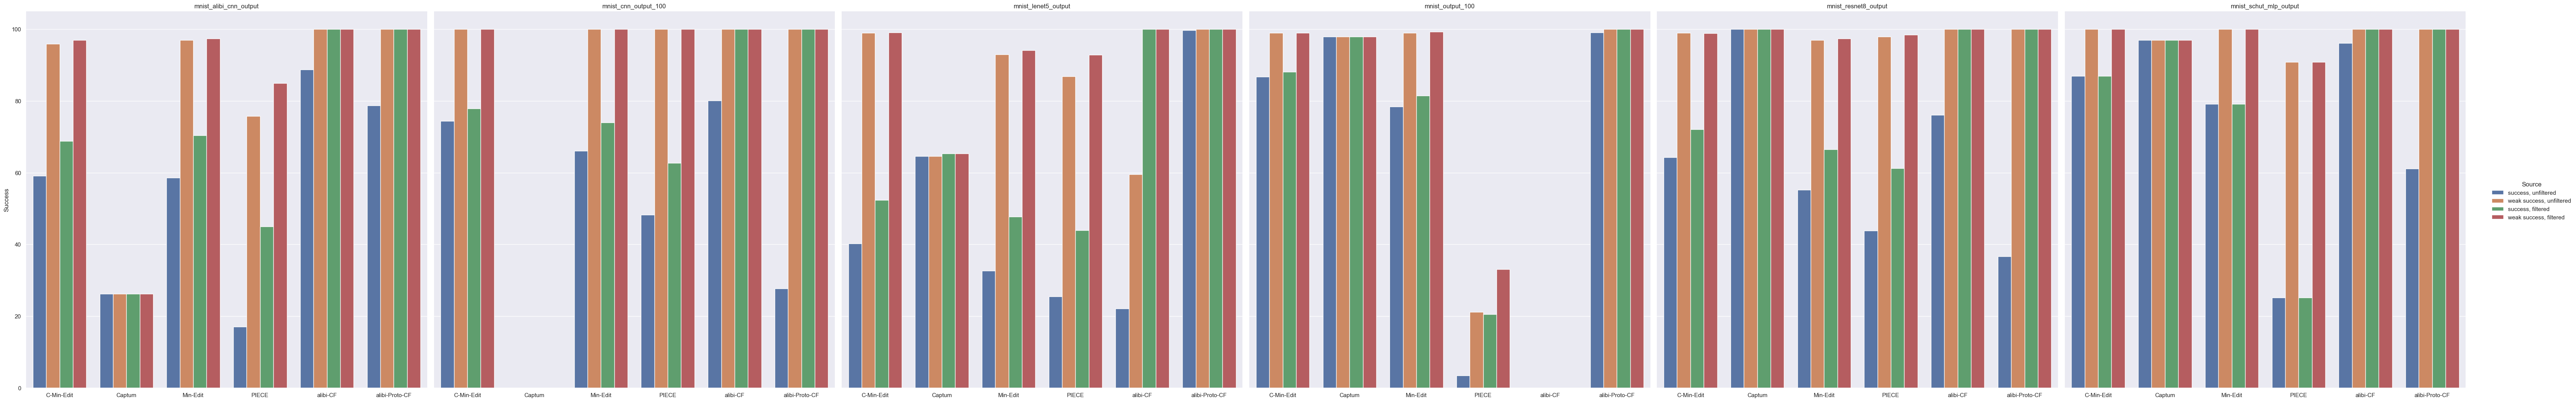

In [284]:
g = sns.catplot(
    data=df, x="method", y="success", hue="Source", col="network",
    kind="bar", height=11, aspect=1, palette="deep"
)
g.set_axis_labels("", "Success")

g.set_titles("{col_name}")
g.despine(left=True)

So what trends do we see per network? For the network named mnist_cnn_output_100, which is the cnn taken from the PIECE paper, we see that Captum cannot find any explanations, whilst if we use weak correctness as a measure, all other methods are 100\% correct. This changes drastically when we are stricter with our definition of correctness. For example, PIECE jumps from less than 50\% correctly explained instances to 100 if you count that at least 1 explanation correct per instance is enough. This implies that these methods only perform well if the decision boundary is 'easy'. Further investigation is needed to confirm this implication. Looking at the network named mnist_output_100, which is a simple mlp and the only network that was not trained by us (the network was sourced from a neural network verification benchmark and the resulting keras and torch weights came from a translated ONNX file). Considering this network is an 'outlier' in this sense, this could be a reason why there is really poor performance using PIECE and alibi-CF (alibi-CF has 0 correct explanations). Another interesting thing to note here is that whilst alibi-CF performs badly here, alibi-Proto-CF performs almost perfectly. This is almost reversed when comparing to mnist_cnn_output_100, where alibi-Proto-CF has very low correctness (it does have high correctness on the explanations it does find). Looking for trends among the other networks, alibi-CF performs better than alibi-Proto-CF on all networks except mnist_cnn_output_100 and mnist_lenet5_output (LeNet5 architecture). 

In [285]:
results['method'] = results.method.replace(to_replace='Captum-MinParamPerturbation', value='Captum')

In [286]:
results.loc[(results['method'] == 'Captum') & (results['success'] == 1), 'success_ratio'] = 1

In [287]:
results[results['method'] == 'Captum'][results['success_ratio'] == 0]

C:\Users\Jasmin\AppData\Local\Temp\ipykernel_23656\2942674561.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  results[results['method'] == 'Captum'][results['success_ratio'] == 0]


,network,image,original_label,original_predicted_label,predicted_label,target,method,IM1,IM2,success,...,linf,implausibility,morans_i_original,morans_i_explanation,morans_i_original_minus_explanation,optim_time,success_ratio,weak_success,morans_i_difference,timeout
2693,mnist_output_100,20.0,9,7,7.0,NaN,Captum,1.0,0.093801,0,...,1.0,829.44600,0.834974,0.808764,0.812074,0.050531,0.0,0,0.026210,0.0
2722,mnist_output_100,49.0,4,9,9.0,NaN,Captum,1.0,0.114168,0,...,1.0,852.26263,0.739501,0.696759,0.693901,0.050866,0.0,0,0.042742,0.0
7227,mnist_cnn_output_100,0.0,7,9,9.0,NaN,Captum,1.0,0.082376,0,...,1.0,366.93380,0.722879,0.706935,0.741051,0.141400,0.0,0,0.015943,0.0
7228,mnist_cnn_output_100,1.0,2,9,9.0,NaN,Captum,1.0,0.072226,0,...,1.0,564.12646,0.762163,0.744027,0.687392,0.111960,0.0,0,0.018136,0.0
7229,mnist_cnn_output_100,2.0,1,9,9.0,NaN,Captum,1.0,0.206293,0,...,1.0,371.35560,0.686809,0.691513,0.687392,0.110921,0.0,0,0.004704,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16427,mnist_lenet5_output,92.0,9,4,4.0,NaN,Captum,1.0,0.043251,0,...,1.0,293.84290,0.590049,0.599904,0.684149,0.057186,0.0,0,0.009855,0.0
16430,mnist_lenet5_output,95.0,4,4,4.0,NaN,Captum,1.0,0.075045,0,...,1.0,339.04034,0.856707,0.788028,0.662047,0.061075,0.0,0,0.068679,0.0
25505,mnist_schut_mlp_output,62.0,9,5,5.0,NaN,Captum,1.0,0.044328,0,...,1.0,343.69183,0.602813,0.596603,0.684203,0.031549,0.0,0,0.006210,0.0
25506,mnist_schut_mlp_output,63.0,3,2,2.0,NaN,Captum,1.0,0.043036,0,...,1.0,340.57126,0.741123,0.746839,0.683676,0.032024,0.0,0,0.005716,0.0


In [315]:
results[results['method'] == 'Captum'][results['success_ratio']]

KeyError: "None of [Index([               0.0,                0.0,                0.0,\n                      0.0,                0.0,                0.0,\n                      0.0,                0.0,                0.0,\n                      0.0,\n       ...\n       0.4444444444444444,                0.0,                0.0,\n                      0.0,                0.0,                0.0,\n                      0.0,                0.0,                0.0,\n                      0.0],\n      dtype='float64', length=27324)] are in the [columns]"

<AxesSubplot:xlabel='method', ylabel='success_ratio'>

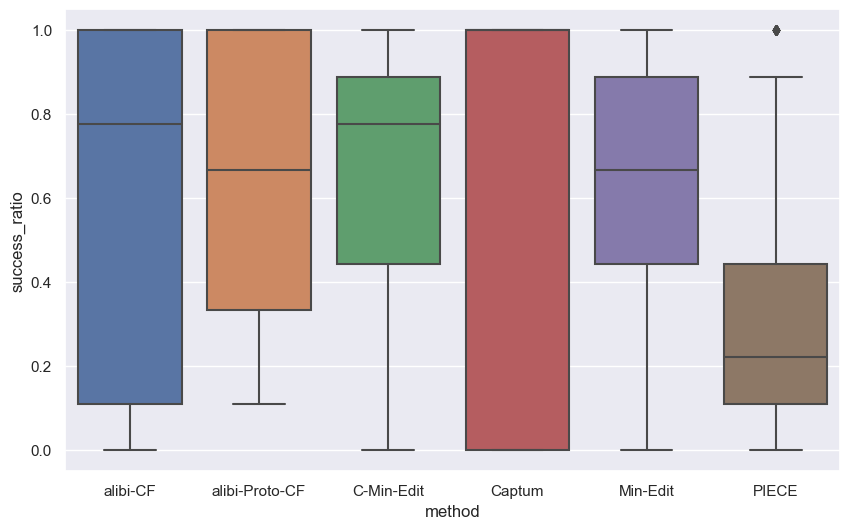

In [288]:
sns.set(rc={'figure.figsize':(10, 6)})
sns.boxplot(x='method', y='success_ratio', data=results, palette='deep')

<AxesSubplot:xlabel='method', ylabel='success_ratio'>

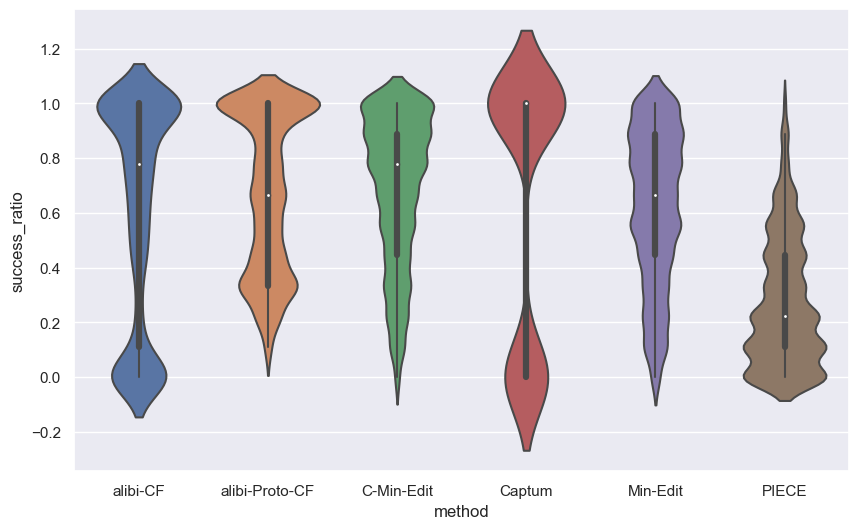

In [289]:
sns.set(rc={'figure.figsize':(10, 6)})
sns.violinplot(x='method', y='success_ratio', data=results, palette='deep')

### Sub question on correctness of decision boundaries

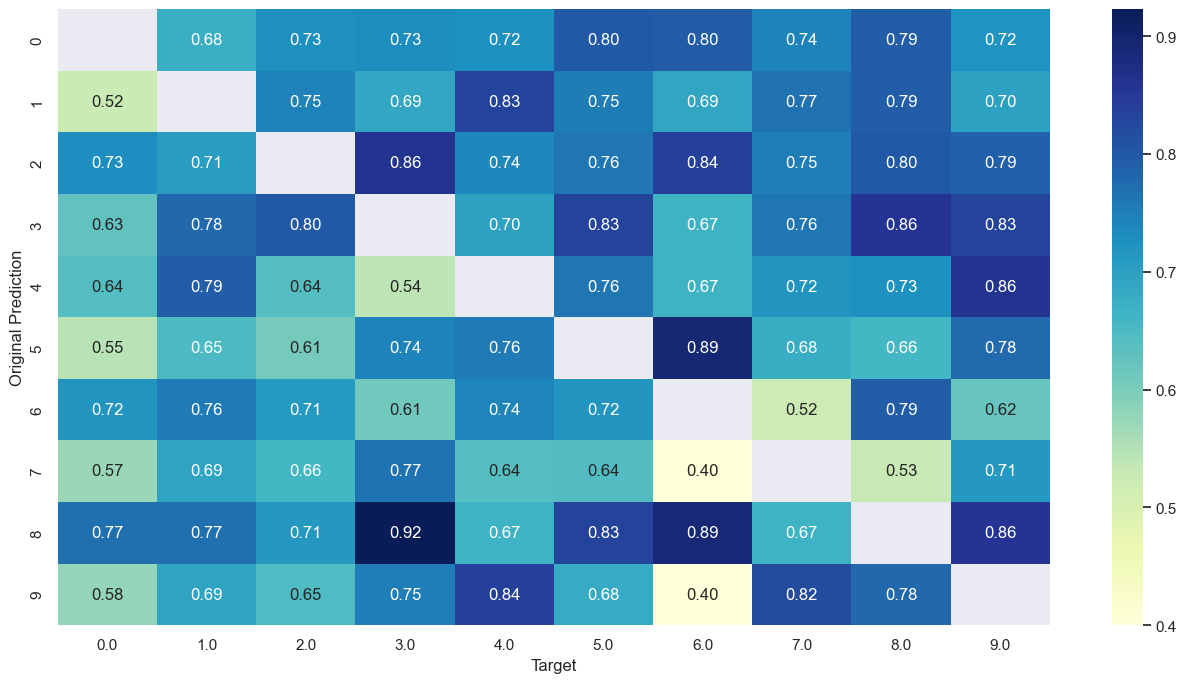

In [291]:
# Add heatmaps next to uncover correctness for each decision boundary per method

grouped_correctness = filtered_results.groupby(['method', 'original_predicted_label', 'target'])['success'].mean()

minedit_correctness = pd.DataFrame(grouped_correctness['Min-Edit'].reset_index()).pivot(index="original_predicted_label", columns="target", values="success")
plt.figure(figsize=(16, 8))  # Set the figure size
sns.heatmap(minedit_correctness, cmap="YlGnBu", cbar=True, annot=True, fmt=".2f")


# Set heatmap title and labels
plt.ylabel('Original Prediction')
plt.xlabel('Target')

# Show the heatmap
plt.show()

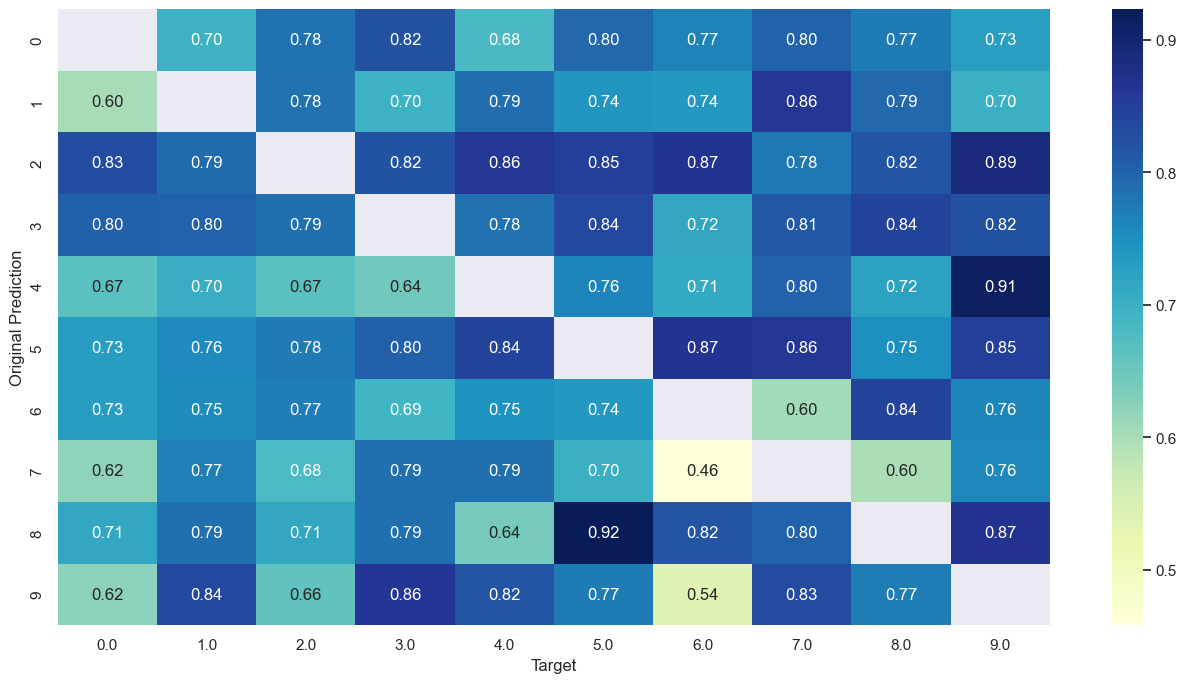

In [292]:
grouped_correctness = filtered_results.groupby(['method', 'original_predicted_label', 'target'])['success'].mean()
cminedit_correctness = pd.DataFrame(grouped_correctness['C-Min-Edit'].reset_index()).pivot(index="original_predicted_label", columns="target", values="success")
plt.figure(figsize=(16, 8))  # Set the figure size
sns.heatmap(cminedit_correctness, cmap="YlGnBu", annot=True, fmt=".2f")


# Set heatmap title and labels
plt.ylabel('Original Prediction')
plt.xlabel('Target')

# Show the heatmap
plt.show()

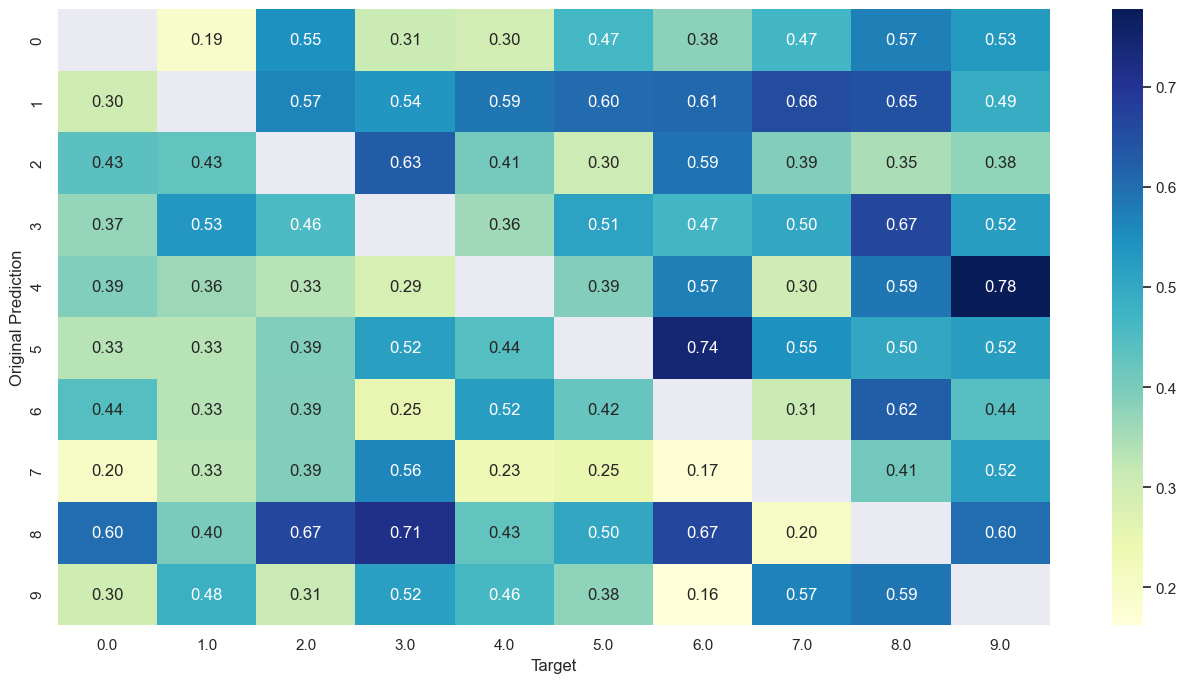

In [293]:
grouped_correctness = filtered_results.groupby(['method', 'original_predicted_label', 'target'])['success'].mean()
piece_correctness = pd.DataFrame(grouped_correctness['PIECE'].reset_index()).pivot(index="original_predicted_label", columns="target", values="success")
plt.figure(figsize=(16, 8))  # Set the figure size
sns.heatmap(piece_correctness, cmap="YlGnBu", annot=True, fmt=".2f")


# Set heatmap title and labels
plt.ylabel('Original Prediction')
plt.xlabel('Target')

# Show the heatmap
plt.show()

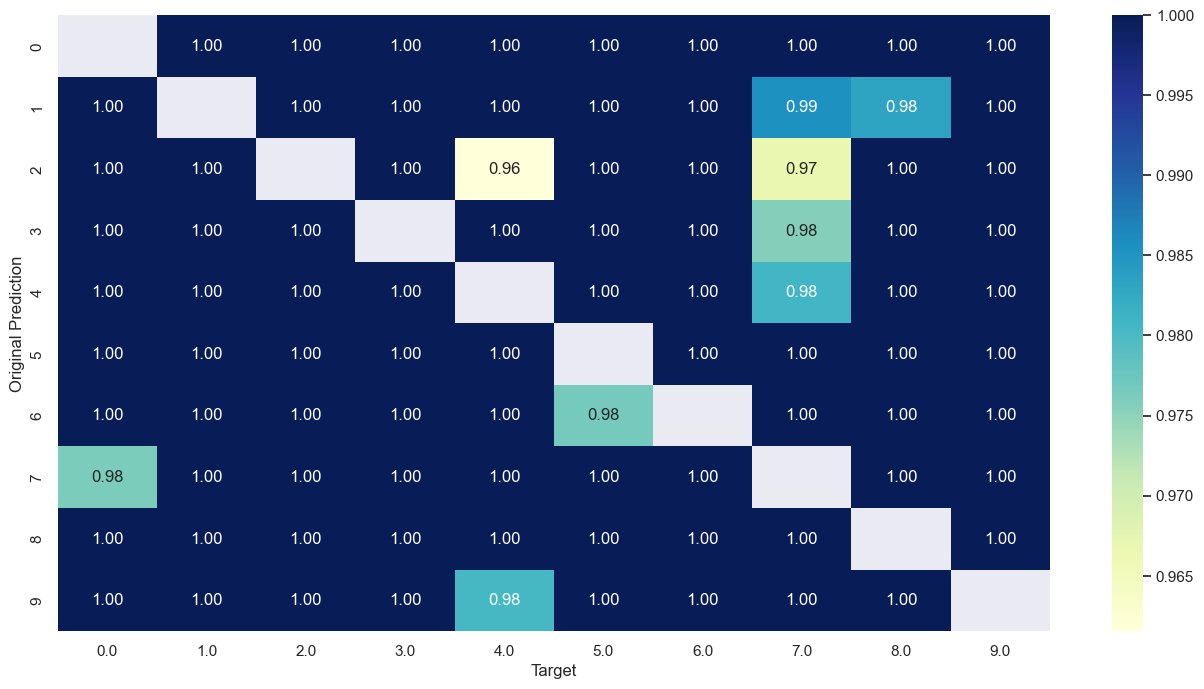

In [294]:
grouped_correctness = filtered_results.groupby(['method', 'original_predicted_label', 'target'])['success'].mean()
alibiCF_correctness = pd.DataFrame(grouped_correctness['alibi-CF'].reset_index()).pivot(index="original_predicted_label", columns="target", values="success")
plt.figure(figsize=(16, 8))  # Set the figure size
sns.heatmap(alibiCF_correctness, cmap="YlGnBu", cbar=True, annot=True, fmt=".2f")


# Set heatmap title and labels
plt.ylabel('Original Prediction')
plt.xlabel('Target')

# Show the heatmap
plt.show()

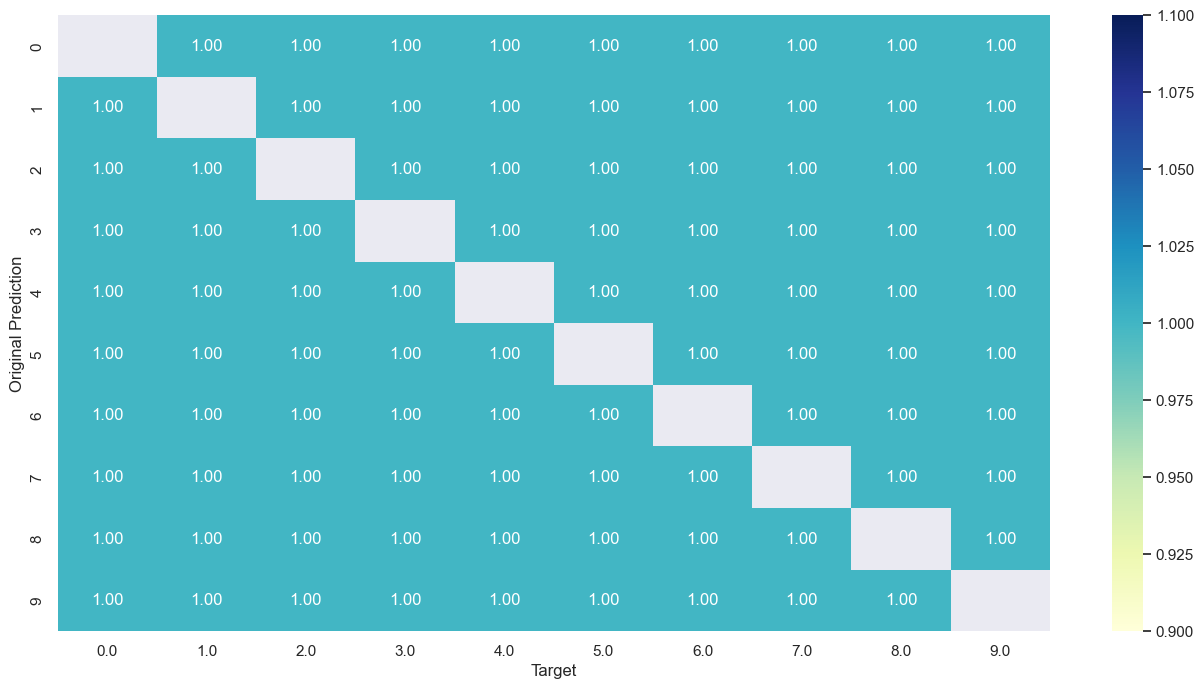

In [295]:
grouped_correctness = filtered_results.groupby(['method', 'original_predicted_label', 'target'])['success'].mean()
alibiProtoCF_correctness = pd.DataFrame(grouped_correctness['alibi-Proto-CF'].reset_index()).pivot(index="original_predicted_label", columns="target", values="success")
plt.figure(figsize=(16, 8))  # Set the figure size
sns.heatmap(alibiProtoCF_correctness, cmap="YlGnBu", cbar=True, annot=True, fmt=".2f")


# Set heatmap title and labels
plt.ylabel('Original Prediction')
plt.xlabel('Target')

# Show the heatmap
plt.show()

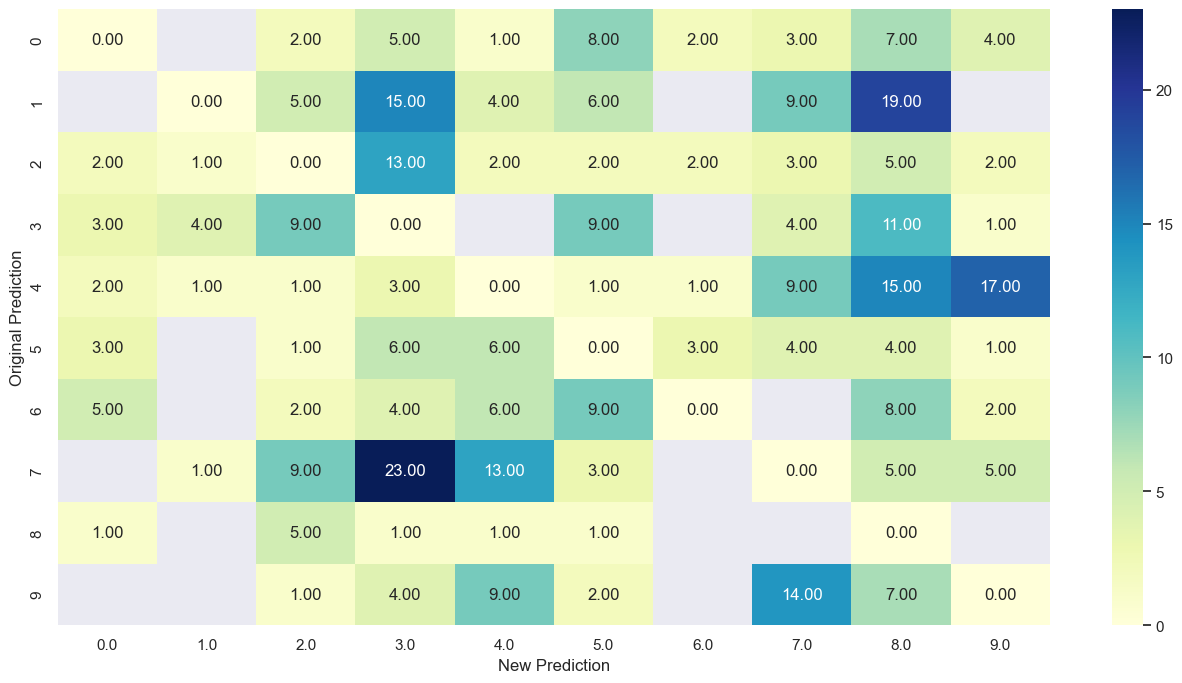

In [296]:
grouped_correctness = filtered_results.groupby(['method', 'original_predicted_label', 'predicted_label'])['success'].sum()
captum_correctness = pd.DataFrame(grouped_correctness['Captum-MinParamPerturbation'].reset_index()).pivot(index="original_predicted_label", columns="predicted_label", values="success")
plt.figure(figsize=(16, 8))  # Set the figure size
# aptum-MinParamPerturbation
sns.heatmap(captum_correctness, cmap="YlGnBu", cbar=True, annot=True, fmt=".2f")


# Set heatmap title and labels
plt.ylabel('Original Prediction')
plt.xlabel('New Prediction')

# Show the heatmap
plt.show()

## Question 2: are there correlations between correctness and the other metrics?

In [297]:
results

,network,image,original_label,original_predicted_label,predicted_label,target,method,IM1,IM2,success,...,linf,implausibility,morans_i_original,morans_i_explanation,morans_i_original_minus_explanation,optim_time,success_ratio,weak_success,morans_i_difference,timeout
0,mnist_output_100,0.0,7,7,NaN,0.0,alibi-CF,NaN,NaN,0,...,NaN,NaN,0.722879,NaN,NaN,4.768510,0.0,0,NaN,1.0
1,mnist_output_100,0.0,7,7,NaN,1.0,alibi-CF,NaN,NaN,0,...,NaN,NaN,0.722879,NaN,NaN,4.600064,0.0,0,NaN,1.0
2,mnist_output_100,0.0,7,7,NaN,2.0,alibi-CF,NaN,NaN,0,...,NaN,NaN,0.722879,NaN,NaN,3.915866,0.0,0,NaN,1.0
3,mnist_output_100,0.0,7,7,NaN,3.0,alibi-CF,NaN,NaN,0,...,NaN,NaN,0.722879,NaN,NaN,3.973385,0.0,0,NaN,1.0
4,mnist_output_100,0.0,7,7,NaN,4.0,alibi-CF,NaN,NaN,0,...,NaN,NaN,0.722879,NaN,NaN,3.924591,0.0,0,NaN,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27319,mnist_schut_mlp_output,98.0,6,6,6.0,4.0,PIECE,1.0,0.051976,0,...,1.992157,342.92554,0.709559,0.586605,0.519112,29.422554,0.0,0,0.122954,0.0
27320,mnist_schut_mlp_output,98.0,6,6,6.0,5.0,PIECE,1.0,0.027526,0,...,1.991785,399.54440,0.709559,0.688892,0.462643,29.331965,0.0,0,0.020667,0.0
27321,mnist_schut_mlp_output,98.0,6,6,6.0,7.0,PIECE,1.0,0.029841,0,...,1.992157,433.02762,0.709559,0.659100,0.502906,29.518147,0.0,0,0.050459,0.0
27322,mnist_schut_mlp_output,98.0,6,6,6.0,8.0,PIECE,1.0,0.028693,0,...,1.984222,465.63928,0.709559,0.653260,0.591543,29.591588,0.0,0,0.056299,0.0


<AxesSubplot:xlabel='success', ylabel='optim_time'>

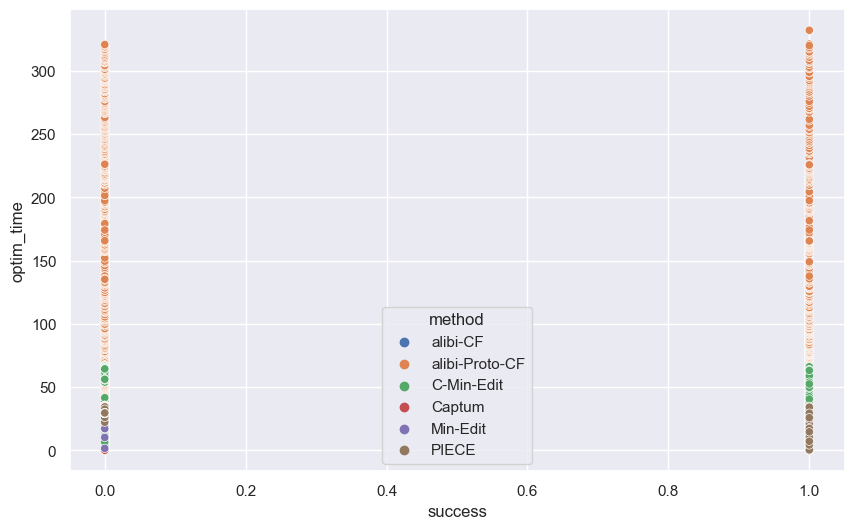

In [298]:
sns.scatterplot(data=results, x="success", y="optim_time", hue="method", palette="deep")

In [299]:
filtered_results['method'] = filtered_results.method.replace(to_replace='Captum-MinParamPerturbation', value='Captum')

C:\Users\Jasmin\AppData\Local\Temp\ipykernel_23656\2440910950.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_results['method'] = filtered_results.method.replace(to_replace='Captum-MinParamPerturbation', value='Captum')


## Question 4: How do the different methods perform across different neural architectures with the different metrics?

In [300]:
# Let's investigate the same question but also group by network
mean_optim_time = results.groupby(['method', 'network'])['optim_time'].mean()
print(mean_optim_time)

df_optimtime = mean_optim_time.reset_index()

method          network               
C-Min-Edit      mnist_alibi_cnn_output     47.381084
                mnist_cnn_output_100       28.458221
                mnist_lenet5_output        41.752142
                mnist_output_100           23.284433
                mnist_resnet8_output       40.637512
                mnist_schut_mlp_output     21.390629
Captum          mnist_alibi_cnn_output      0.130304
                mnist_cnn_output_100        0.110689
                mnist_lenet5_output         0.059915
                mnist_output_100            0.050793
                mnist_resnet8_output        0.133730
                mnist_schut_mlp_output      0.031891
Min-Edit        mnist_alibi_cnn_output     23.097676
                mnist_cnn_output_100       19.876295
                mnist_lenet5_output        23.859060
                mnist_output_100           12.595900
                mnist_resnet8_output       24.478119
                mnist_schut_mlp_output     12.690207
PIECE  

In [301]:
# Let's investigate the same question but also group by network
mean_optim_time = filtered_results.groupby(['method', 'network'])['optim_time'].mean()
print(mean_optim_time)

df_optimtime_filtered = mean_optim_time.reset_index()

method          network               
C-Min-Edit      mnist_alibi_cnn_output     43.873091
                mnist_cnn_output_100       26.974139
                mnist_lenet5_output        38.543241
                mnist_output_100           22.725329
                mnist_resnet8_output       36.270350
                mnist_schut_mlp_output     21.390629
Captum          mnist_alibi_cnn_output      0.130304
                mnist_cnn_output_100        0.110689
                mnist_lenet5_output         0.059681
                mnist_output_100            0.050793
                mnist_resnet8_output        0.133730
                mnist_schut_mlp_output      0.031891
Min-Edit        mnist_alibi_cnn_output     19.678296
                mnist_cnn_output_100       17.824891
                mnist_lenet5_output        21.247350
                mnist_output_100           11.955916
                mnist_resnet8_output       21.004913
                mnist_schut_mlp_output     12.690207
PIECE  

In [302]:
df_optimtime['Source'] = 'unfiltered'
df_optimtime_filtered['Source'] = 'filtered'

# Combine the DataFrames
df = pd.concat([df_optimtime, df_optimtime_filtered], ignore_index=True)
df

,method,network,optim_time,Source
0,C-Min-Edit,mnist_alibi_cnn_output,47.381084,unfiltered
1,C-Min-Edit,mnist_cnn_output_100,28.458221,unfiltered
2,C-Min-Edit,mnist_lenet5_output,41.752142,unfiltered
3,C-Min-Edit,mnist_output_100,23.284433,unfiltered
4,C-Min-Edit,mnist_resnet8_output,40.637512,unfiltered
...,...,...,...,...
67,alibi-Proto-CF,mnist_cnn_output_100,176.951883,filtered
68,alibi-Proto-CF,mnist_lenet5_output,81.884415,filtered
69,alibi-Proto-CF,mnist_output_100,66.162058,filtered
70,alibi-Proto-CF,mnist_resnet8_output,151.944124,filtered


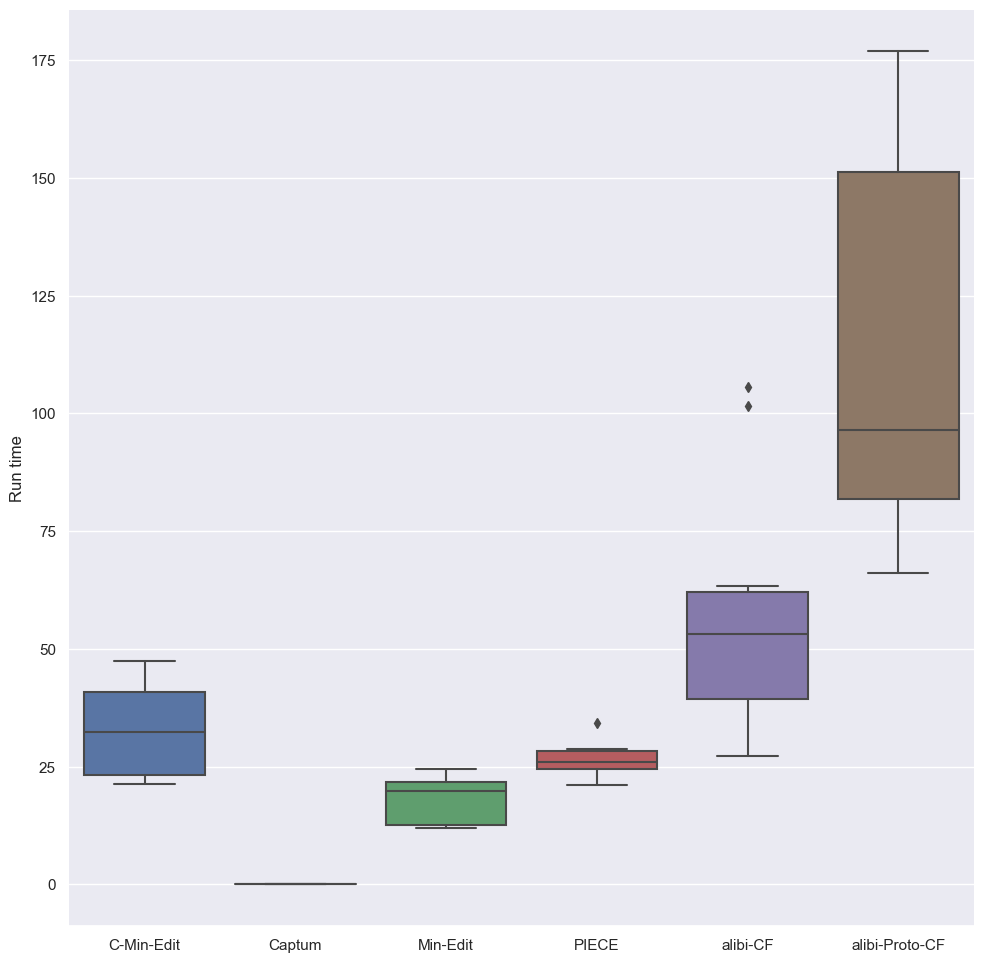

In [308]:
g = sns.catplot(
    data=df, x="method", y="optim_time", 
    kind="box", height=10, aspect=1, palette="deep"
)
g.set_axis_labels("", "Run time")

g.set_titles("{col_name}")
g.despine(left=True)

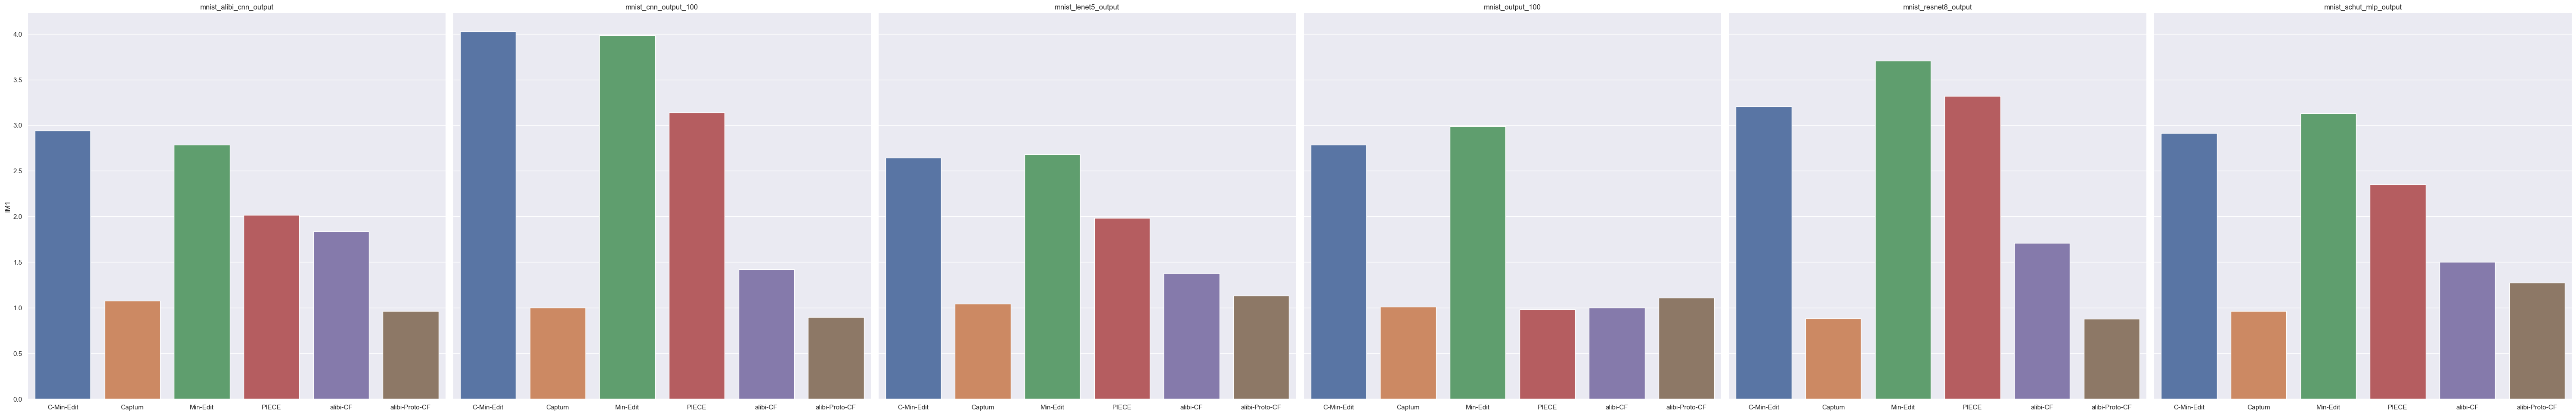

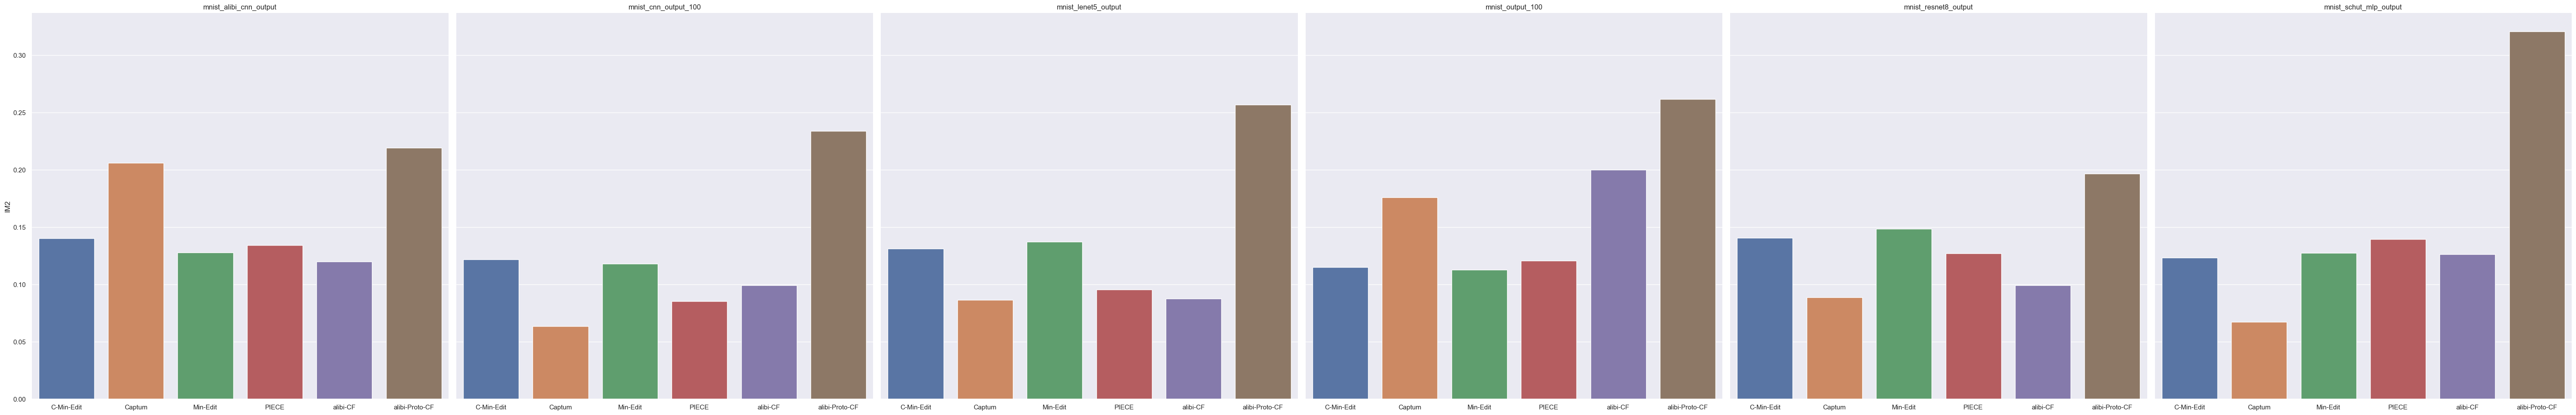

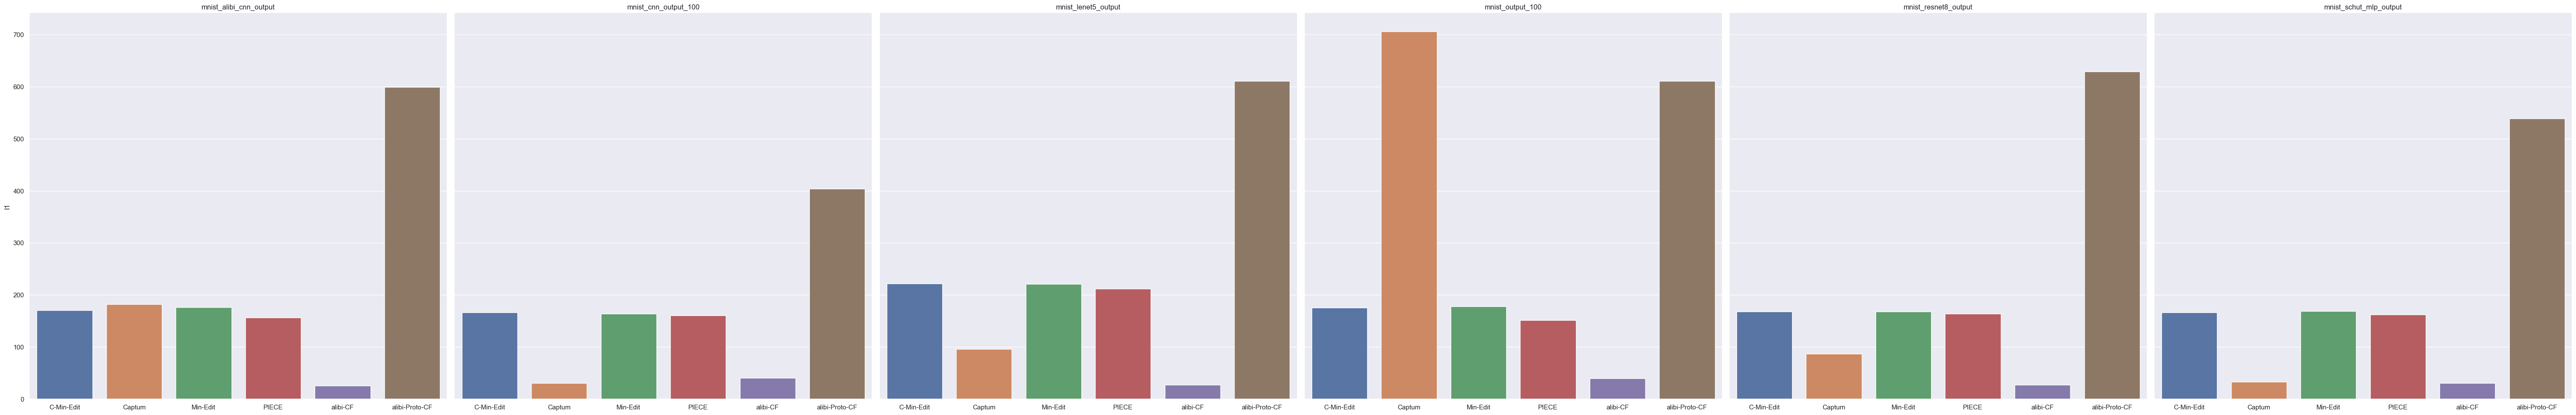

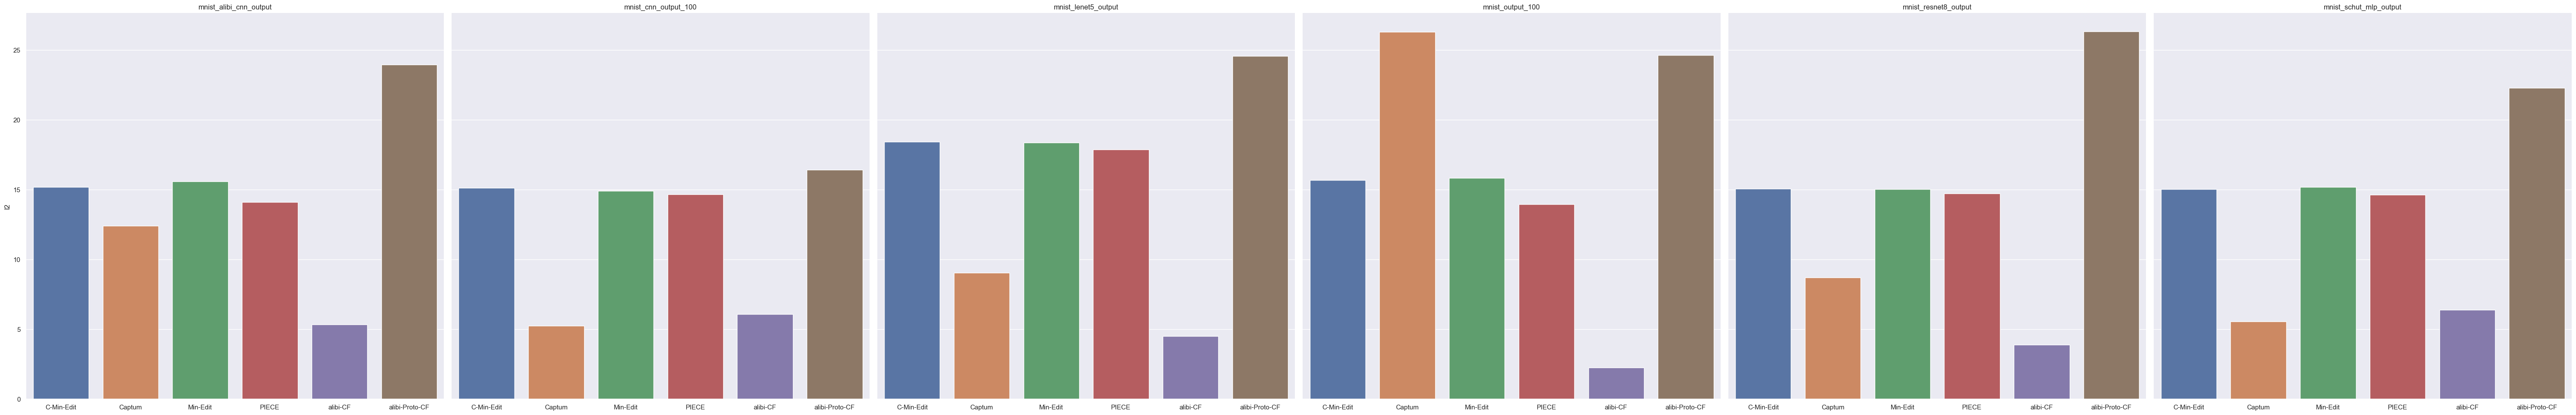

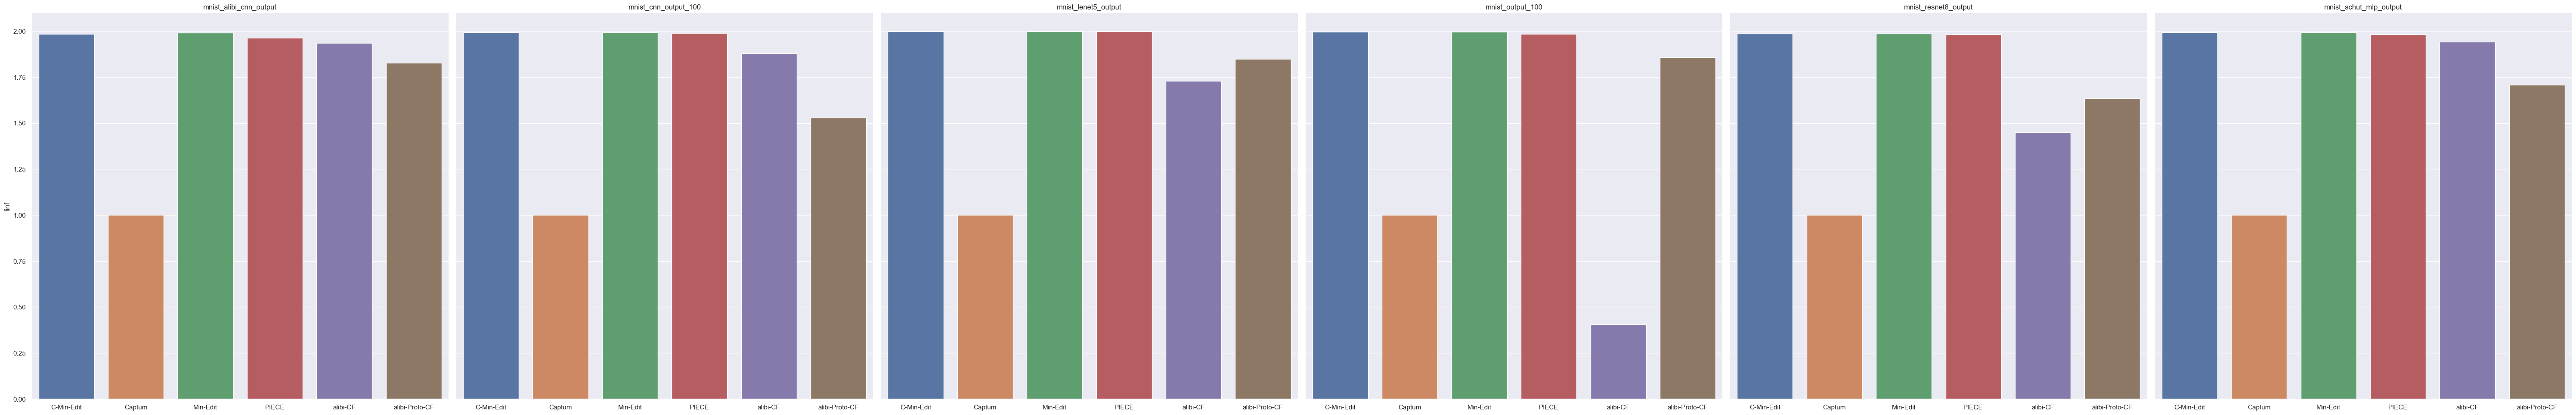

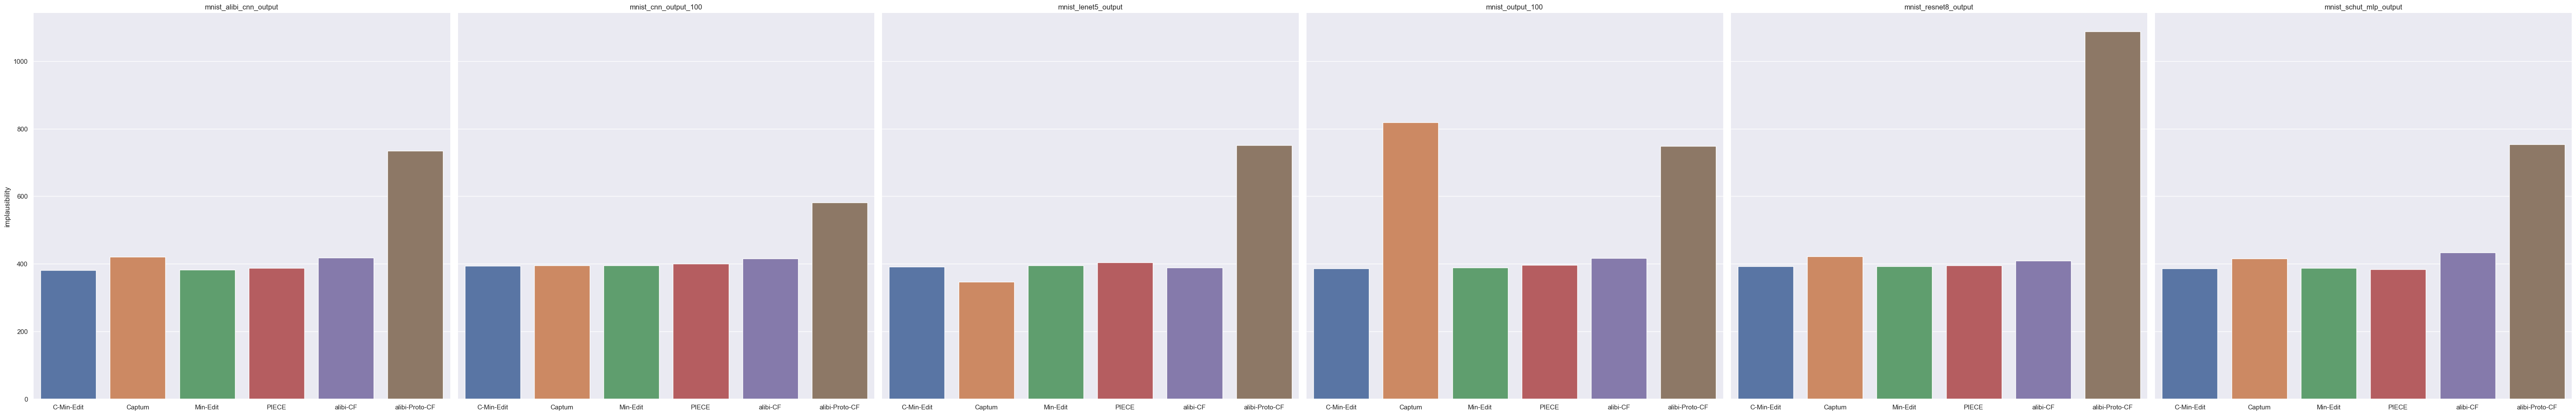

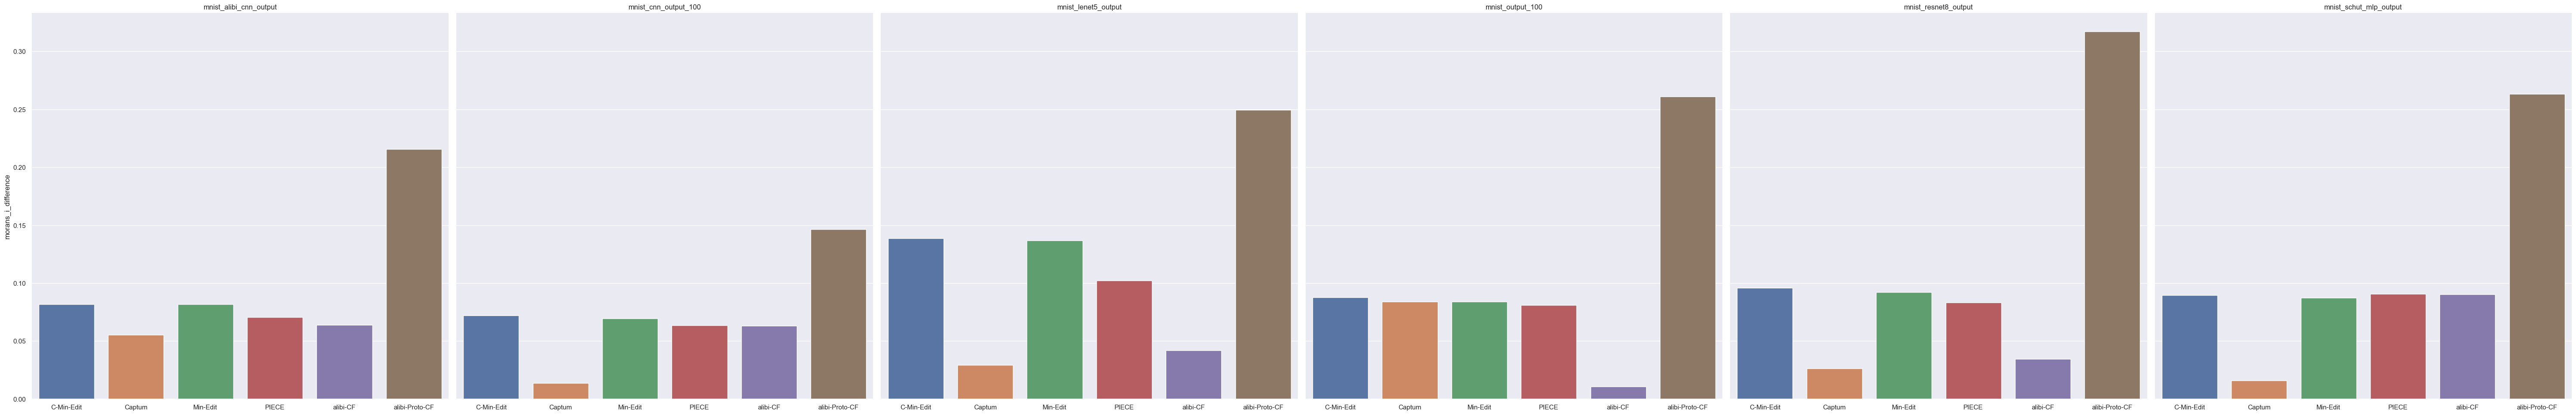

In [304]:
# Let's investigate the same question but also group by network
metrics = ['IM1', 'IM2', 'l1', 'l2', 'linf', 'implausibility', 'morans_i_difference']

for metric in metrics:
    mean_metric = results.groupby(['method', 'network'])[metric].mean().reset_index()
    #mean_metric['method'] = mean_metric.method.replace(to_replace='Captum-MinParamPerturbation', value='Captum')
    g = sns.catplot(
        data=mean_metric, x="method", y=metric, col="network",
        kind="bar", height=10, aspect=1, palette="deep"
    )
    g.set_axis_labels("", metric)

    g.set_titles("{col_name}")
    g.despine(left=True)


## Just investigating Moran's i

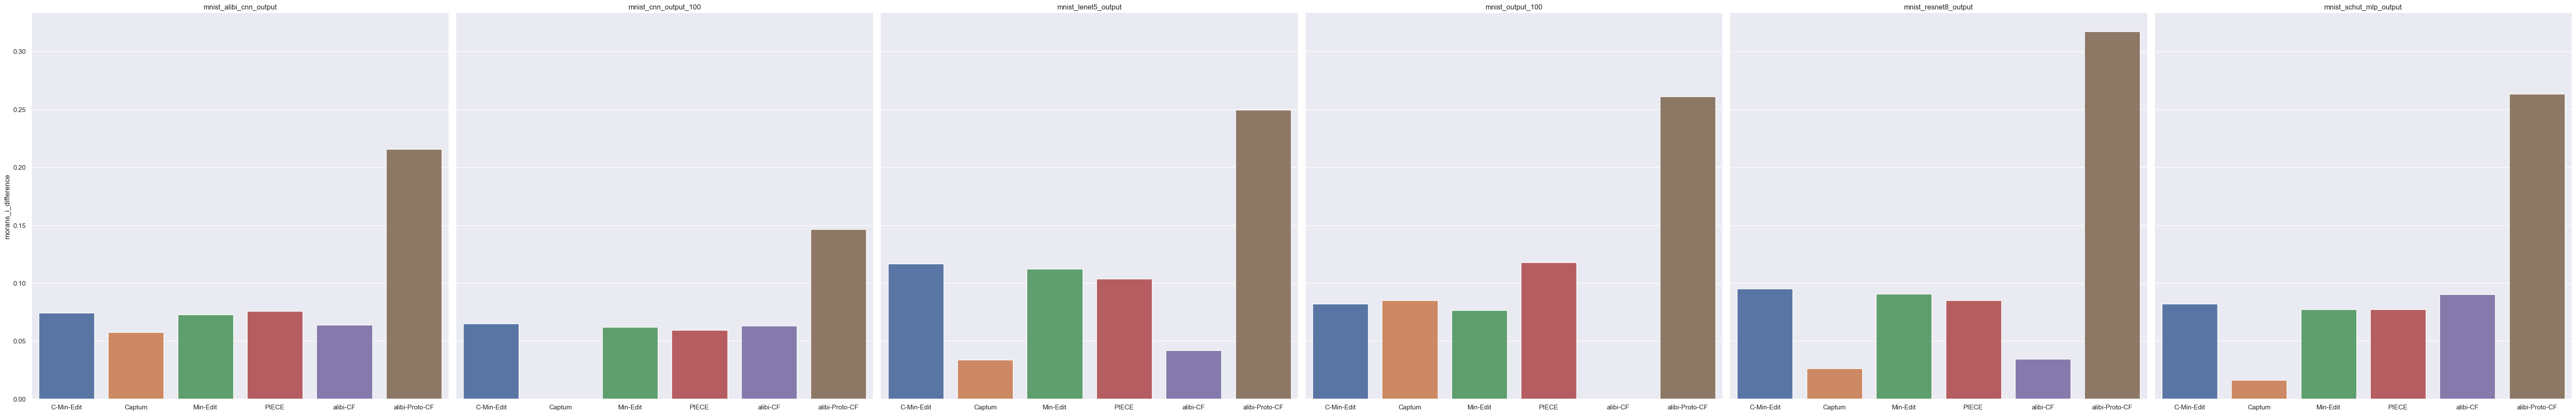

In [305]:
metric = 'morans_i_difference'
only_correct_results = results[results['success'] == 1]
mean_metric = only_correct_results.groupby(['method', 'network'])[metric].mean().reset_index()

g = sns.catplot(
        data=mean_metric, x="method", y=metric, col="network",
        kind="bar", height=10, aspect=1, palette="deep"
    )
g.set_axis_labels("", metric)

g.set_titles("{col_name}")
g.despine(left=True)

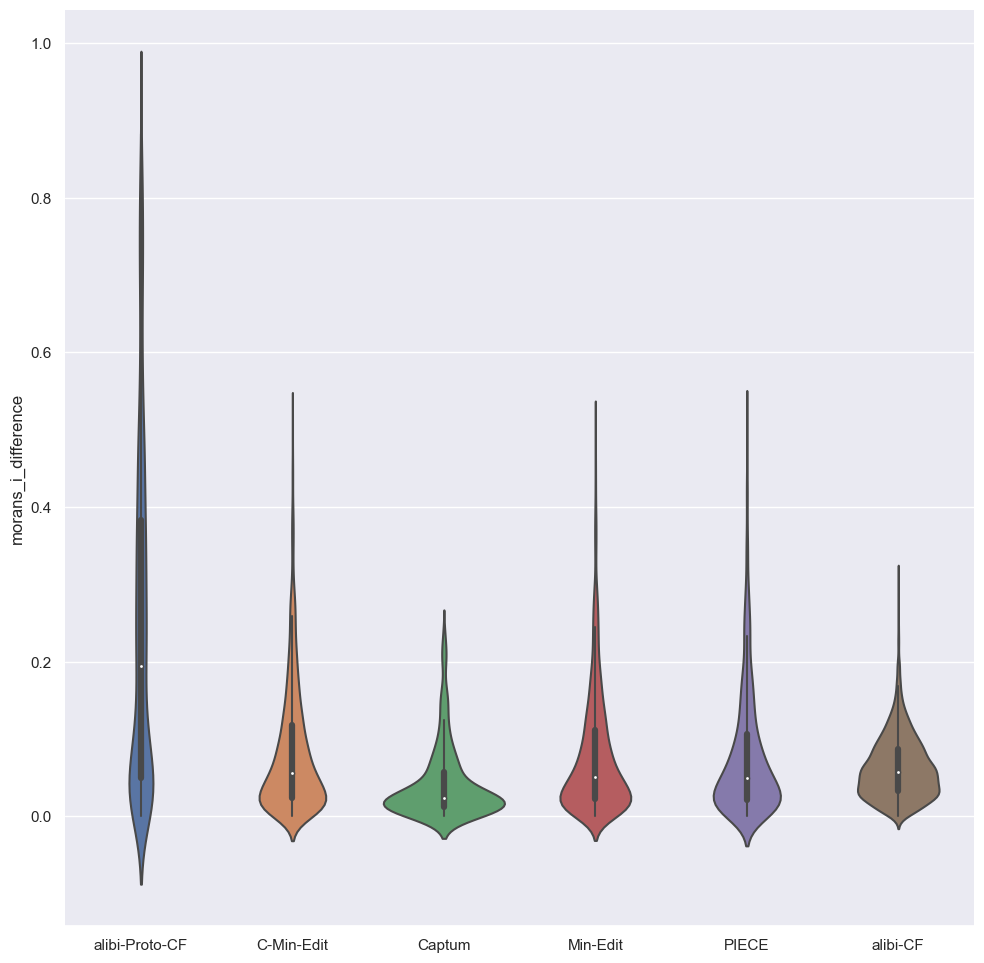

In [306]:
metric = 'morans_i_difference'
only_correct_results = results[results['success'] == 1]

g = sns.catplot(
        data=only_correct_results, x="method", y=metric,
        kind="violin", height=10, aspect=1, palette="deep"
    )
g.set_axis_labels("", metric)

g.set_titles("{col_name}")
g.despine(left=True)

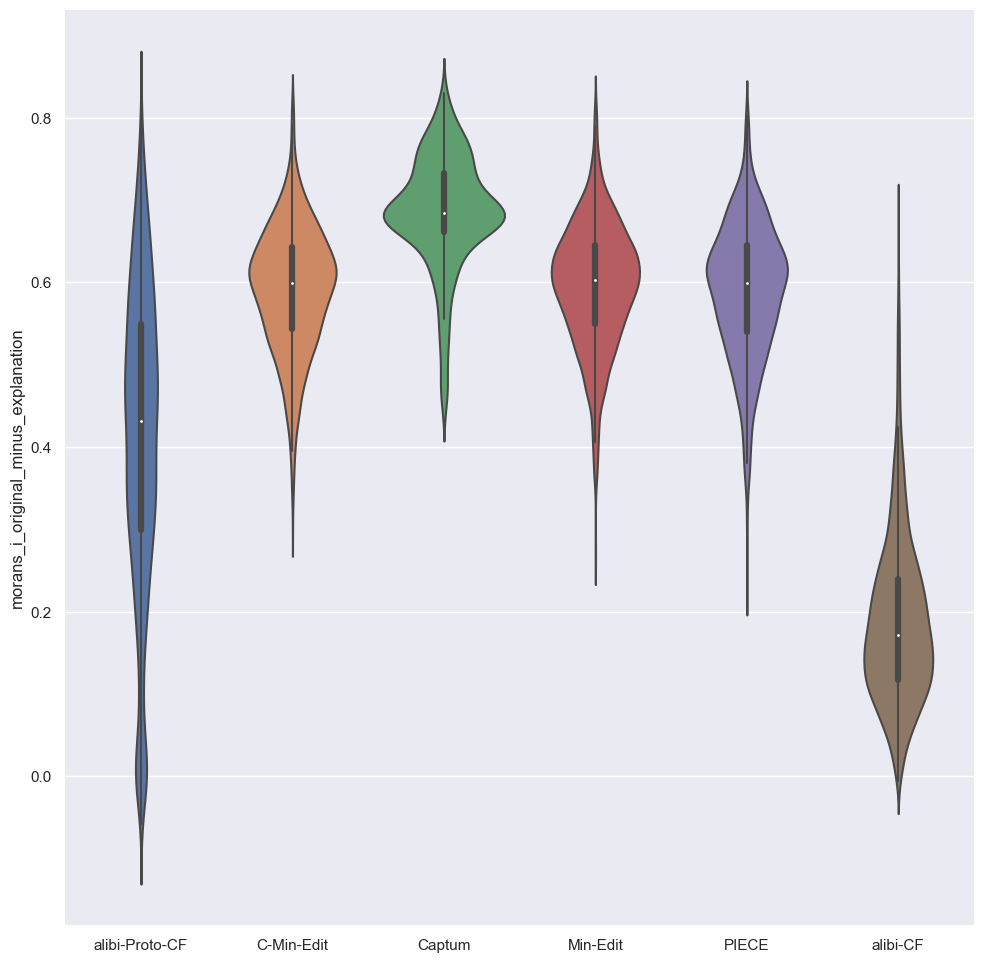

In [307]:
metric = 'morans_i_original_minus_explanation'
only_correct_results = results[results['success'] == 1]

g = sns.catplot(
        data=only_correct_results, x="method", y=metric,
        kind="violin", height=10, aspect=1, palette="deep"
    )
g.set_axis_labels("", metric)

g.set_titles("{col_name}")
g.despine(left=True)

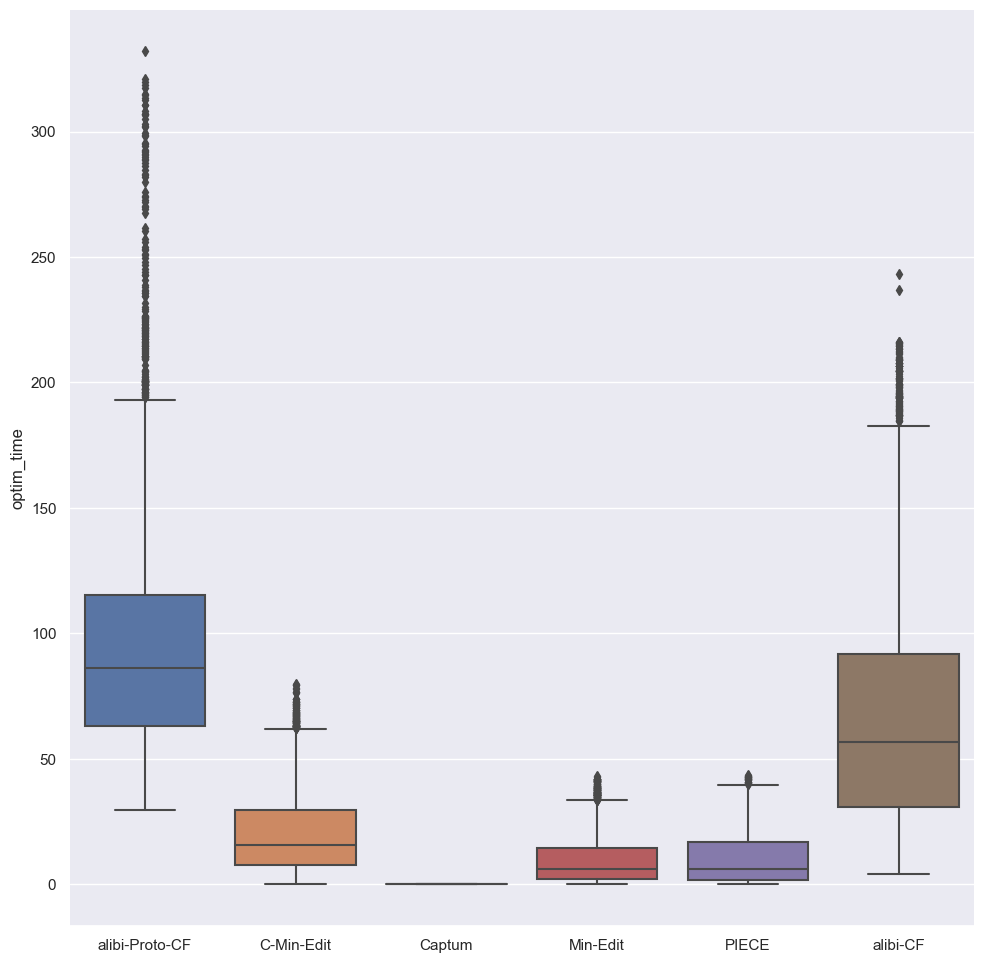

In [314]:
metric = 'optim_time'
only_correct_results = results[results['success'] == 1]

g = sns.catplot(
        data=only_correct_results, x="method", y=metric,
        kind="box", height=10, aspect=1, palette="deep"
    )
g.set_axis_labels("", metric)

g.set_titles("{col_name}")
g.despine(left=True)

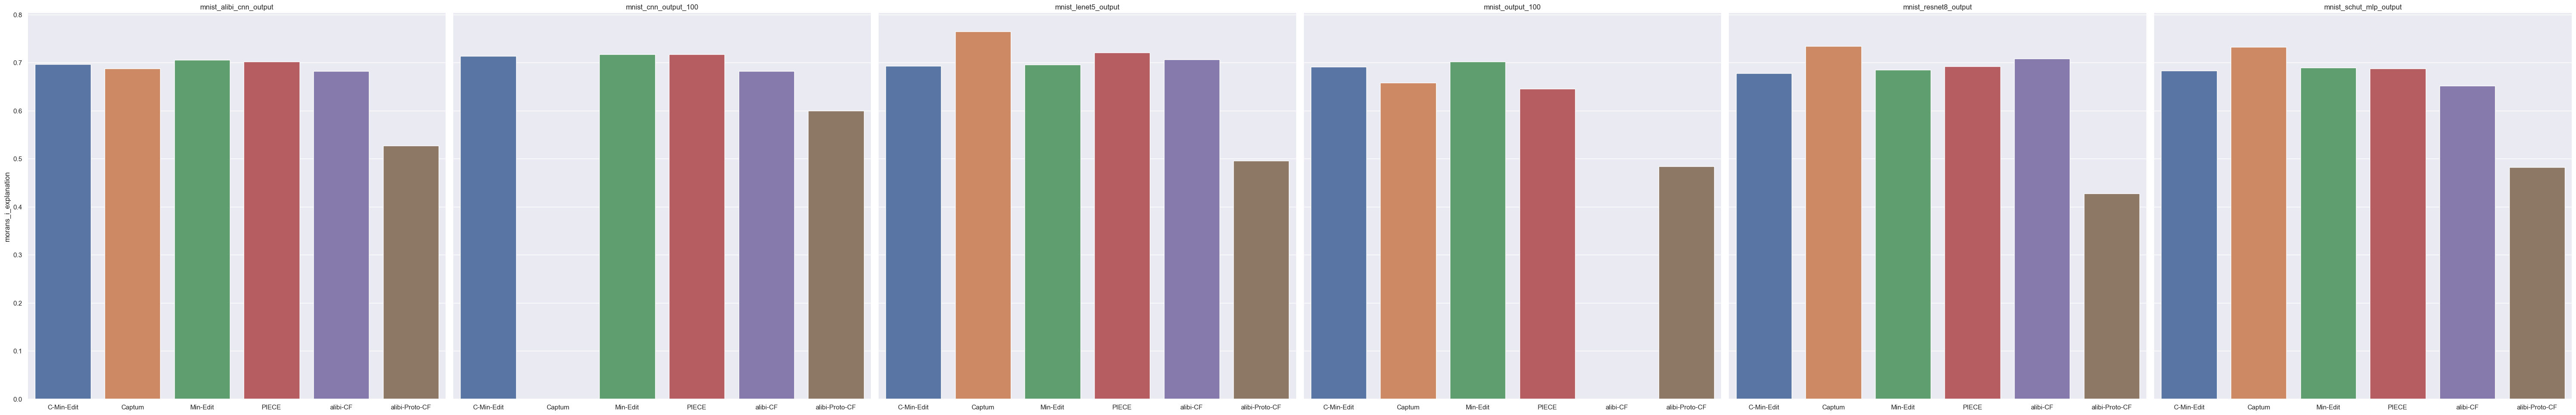

In [252]:
metric = 'morans_i_explanation'
only_correct_results = results[results['success'] == 1]
mean_metric = only_correct_results.groupby(['method', 'network'])[metric].mean().reset_index()

g = sns.catplot(
        data=mean_metric, x="method", y=metric, col="network",
        kind="bar", height=10, aspect=1, palette="deep"
    )
g.set_axis_labels("", metric)

g.set_titles("{col_name}")
g.despine(left=True)

In [257]:
only_correct_results = filtered_results[filtered_results['success'] == 1]

In [258]:
# Let's investigate the same question but also group by network
mean_moransi = only_correct_results.groupby(['network', 'method'])['morans_i_difference'].mean()
print(mean_moransi)

df_moransi = mean_moransi.reset_index()

network                 method        
mnist_alibi_cnn_output  C-Min-Edit        0.074185
                        Captum            0.057462
                        Min-Edit          0.072987
                        PIECE             0.075664
                        alibi-CF          0.064024
                        alibi-Proto-CF    0.215516
mnist_cnn_output_100    C-Min-Edit        0.064895
                        Min-Edit          0.062122
                        PIECE             0.059389
                        alibi-CF          0.063013
                        alibi-Proto-CF    0.146532
mnist_lenet5_output     C-Min-Edit        0.116589
                        Captum            0.033853
                        Min-Edit          0.112098
                        PIECE             0.103867
                        alibi-CF          0.041965
                        alibi-Proto-CF    0.249646
mnist_output_100        C-Min-Edit        0.082300
                        Captum            0